# Baby Shopper Profiling — Phase 1
## Behavioral & Temporal Shopper Intelligence

**Objective:** Establish a data-driven, time-aware understanding of how baby shoppers behave — grounded entirely in observed transaction data.

**Scope (Phase 1):**
- Temporal behavioral features: frequency, cadence, burst, activity span, recency
- Spend-based profiling
- Category journey signals
- Behavioral clustering

**Data:** `combined_shoppers.parquet`
- 8.3M rows | 7 columns
- Columns: `gcr_persistent_id`, `header_tran_date`, `department_cleaned`, `subclass_cleaned`, `subclass`, `total_sales`, `total_units`

**Phase 2 (out of scope here):** Predictive modeling, lifecycle transition detection


---
## 1. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ── Visual theme ───────────────────────────────────────────────────────────────
PALETTE = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#762A83', '#F46D43']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 12,
                     'axes.titleweight': 'bold', 'figure.titlesize': 13})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Constants ──────────────────────────────────────────────────────────────────
EPISODE_GAP_DAYS   = 14    # gap (days) that signals a break between purchase episodes
BULK_PERCENTILE    = 0.90  # upper decile of daily units = bulk purchase day
OBSERVATION_MONTHS = 12    # rolling observation window
RANDOM_STATE       = 42

print("Setup complete.")


Setup complete.


---
## 2. Data Loading & Cleaning

In [2]:
raw = pd.read_parquet(r"C:\Users\dacdatalabs.ojt2\Desktop\workspace\DS\datasets\combined_shoppers.parquet")
print(f"Raw shape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")
raw.head(3)


Raw shape: (8320948, 7)
Columns: ['gcr_persistent_id', 'header_tran_date', 'department_cleaned', 'subdepartment_cleaned', 'subclass', 'total_sales', 'total_units']


,gcr_persistent_id,header_tran_date,department_cleaned,subdepartment_cleaned,subclass,total_sales,total_units
0,id-2024042312270501717852-01-irz7p-bkor-uul9-g...,13 Apr 2025,Babies' Wear,Newborn Essential 0-12 Mos,Md Promo,280.000,1
1,id-20240423122704961961115-01-8y9mw-jxx6-dohu-...,4 Apr 2025,Babies' Wear,Newborn Essential 0-12 Mos,Md Promo,510.000,2
2,id-20240423122706217217036-01-bp1ai-zbqq-466i-...,19 Apr 2025,Babies Accs & Furn,Nursing & Feeding,Sc Nursing Supplies & Acc,159.000,1


In [3]:
raw["header_tran_date"] = raw["header_tran_date"].str.replace("Sept", "Sep", case=False)
raw["header_tran_date"].unique()

<ArrowStringArray>
['13 Apr 2025',  '4 Apr 2025', '19 Apr 2025',  '1 Apr 2025', '26 Apr 2025',
 '23 Apr 2025', '12 Apr 2025',  '3 Apr 2025', '11 Apr 2025', '16 Apr 2025',
 ...
  '9 Sep 2025', '10 Sep 2025',  '8 Sep 2025', '20 Sep 2025', '12 Sep 2025',
 '11 Sep 2025',  '3 Sep 2025',  '4 Sep 2025', '25 Sep 2025', '18 Sep 2025']
Length: 365, dtype: str

In [4]:
# ── 2.1 Normalise text fields ─────────────────────────────────────────────────
for col in ['department_cleaned', 'subclass']:
    raw[col] = raw[col].str.lower().str.strip()

# ── 2.2 Parse dates ───────────────────────────────────────────────────────────
raw['date'] = pd.to_datetime(raw['header_tran_date'], format='%d %b %Y', errors='coerce')
n_bad = raw['date'].isna().sum()
print(f"Unparseable dates: {n_bad:,}")
raw = raw.dropna(subset=['date', 'gcr_persistent_id'])

# ── 2.3 Remove promotional / clearance rows ───────────────────────────────────
PROMO_FILTERS = [
    ('subclass',              'md promo'),
    ('subclass', 'iw promotions'),
    ('subclass', 'iaf clearance'),
    ('subclass', 'iaf promotions'),
]
before = len(raw)
for col, val in PROMO_FILTERS:
    raw = raw[raw[col] != val]
print(f"Removed {before - len(raw):,} promo/clearance rows")

# ── 2.4 Observation window ────────────────────────────────────────────────────
SNAPSHOT_DATE = raw['date'].max()
WINDOW_START  = SNAPSHOT_DATE - pd.DateOffset(months=OBSERVATION_MONTHS)
df = raw[raw['date'] >= WINDOW_START].copy()

print(f"\nObservation window : {WINDOW_START.date()} → {SNAPSHOT_DATE.date()}")
print(f"Rows in window     : {len(df):,}")
print(f"Unique customers   : {df['gcr_persistent_id'].nunique():,}")
print(f"Unique subclasses    : {df['subclass'].nunique()}")


Unparseable dates: 0
Removed 661,715 promo/clearance rows

Observation window : 2024-12-31 → 2025-12-31
Rows in window     : 7,659,233
Unique customers   : 1,483,837
Unique subdepts    : 26


In [5]:
# ── 2.5 Subclass overview ───────────────────────────────────────────────────────
subclass_summary = (
    df.groupby('subclass')
      .agg(rows=('date','count'), customers=('gcr_persistent_id','nunique'),
           total_units=('total_units','sum'), total_sales=('total_sales','sum'))
      .sort_values('customers', ascending=False)
)
print("Top subclasses by customer count:")
subclass_summary.head(15)

Top subdepartments by customer count:


,rows,customers,total_units,total_sales
subdepartment_cleaned,,,,
newborn essential 0-12 mos,1332973,447457,1911128,759257680.570
toiletries,1508008,438327,2453604,519044382.330
nursing & feeding,1081935,416384,1407871,750818898.900
infant shoes,382422,270174,428946,217652446.790
toddler boys casual,495479,257955,668707,372151398.870
baby girl fashion 0-24 mos,404648,248238,516031,182079633.570
toddler girls casual apparel,362987,198063,508697,249614643.640
baby c + o,318217,194155,513810,120813420.020
personal care,228929,142966,248935,101590781.180


In [6]:
# ── 2.6 Encode customer ID (integer for speed) ────────────────────────────────
df['customer_id'] = pd.factorize(df['gcr_persistent_id'])[0]
df['year_month']  = df['date'].dt.to_period('M')
df = df.sort_values(['customer_id', 'date']).reset_index(drop=True)

print(f"Final working dataset: {df.shape}")


Final working dataset: (7659233, 10)


---
## 3. Longitudinal Panel — Customer × Month

A **balanced panel** ensures every customer appears in every month of the observation window — including months with zero activity. This eliminates missing-time bias and enables consistent computation of month-over-month deltas.

> All customers are included regardless of history length, as per project scope.


In [7]:
# ── 3.1 Aggregate to customer × day first ───────────────────────────────────────
daily = (
    df.groupby(['customer_id', 'date'])
      .agg(
          day_transactions = ('date',         'count'),
          day_units        = ('total_units',  'sum'),
          day_sales        = ('total_sales',  'sum'),
          distinct_subclass_day = ('subclass', 'nunique'),
      )
      .reset_index()
)
daily['year_month'] = daily['date'].dt.to_period('M')

# ── 3.2 Aggregate daily → monthly ────────────────────────────────────────────
monthly_raw = (
    daily.groupby(['customer_id', 'year_month'])
         .agg(
             total_transactions   = ('day_transactions',     'sum'),
             total_units          = ('day_units',            'sum'),
             total_spend          = ('day_sales',            'sum'),
             days_active_in_month = ('date',                 'count'),
             last_purchase_date   = ('date',                 'max'),
             distinct_subclass_count = ('distinct_subclass_day', 'max'),
         )
         .reset_index()
)

# ── 3.3 Build balanced grid ───────────────────────────────────────────────────
all_months    = pd.period_range(df['year_month'].min(), df['year_month'].max(), freq='M')
all_customers = df['customer_id'].unique()

panel_index = pd.MultiIndex.from_product(
    [all_customers, all_months], names=['customer_id', 'year_month']
)
panel = pd.DataFrame(index=panel_index).reset_index()
panel = panel.merge(monthly_raw, on=['customer_id','year_month'], how='left')

fill_zero = ['total_transactions','total_units','total_spend',
             'days_active_in_month','distinct_subclass_count']
panel[fill_zero] = panel[fill_zero].fillna(0)
panel['is_active'] = (panel['total_transactions'] > 0).astype(int)

print(f"Balanced panel: {panel.shape[0]:,} rows | "
      f"{len(all_customers):,} customers × {len(all_months)} months")
panel.head(13)


Balanced panel: 17,806,044 rows | 1,483,837 customers × 12 months


,customer_id,year_month,total_transactions,total_units,total_spend,days_active_in_month,last_purchase_date,distinct_subdept_count,is_active
0,0,2025-01,0.000,0.000,0.000,0.000,NaT,0.000,0
1,0,2025-02,0.000,0.000,0.000,0.000,NaT,0.000,0
2,0,2025-03,0.000,0.000,0.000,0.000,NaT,0.000,0
3,0,2025-04,1.000,1.000,159.000,1.000,2025-04-19,1.000,1
4,0,2025-05,0.000,0.000,0.000,0.000,NaT,0.000,0
5,0,2025-06,0.000,0.000,0.000,0.000,NaT,0.000,0
6,0,2025-07,0.000,0.000,0.000,0.000,NaT,0.000,0
7,0,2025-08,0.000,0.000,0.000,0.000,NaT,0.000,0
8,0,2025-09,0.000,0.000,0.000,0.000,NaT,0.000,0
9,0,2025-10,0.000,0.000,0.000,0.000,NaT,0.000,0


---
## 4. Temporal Behavioral Features

Building the **temporal signature** for each shopper across five dimensions:
1. Purchase cadence (inter-purchase gaps)
2. Early engagement speed
3. Activity span
4. Behavioral rhythm (regular vs clustered)
5. Recency


In [8]:
# ── 4.1 Inter-purchase gap (day-level) ────────────────────────────────────────
# Use daily aggregation — one row per customer-day they were active
active_days = (
    daily[['customer_id','date']].drop_duplicates()
         .sort_values(['customer_id','date'])
)
active_days['gap_days'] = (
    active_days.groupby('customer_id')['date'].diff().dt.days
)

gap_stats = (
    active_days.groupby('customer_id')['gap_days']
               .agg(
                   avg_gap_days    = 'mean',
                   median_gap_days = 'median',
                   std_gap_days    = 'std',
                   min_gap_days    = 'min',
                   max_gap_days    = 'max',
               )
               .reset_index()
)
# Purchase regularity: coefficient of variation (lower = more regular)
gap_stats['purchase_regularity_cv'] = (
    gap_stats['std_gap_days'] / gap_stats['avg_gap_days'].clip(lower=0.01)
)

print("Gap statistics sample:")
gap_stats.head()


Gap statistics sample:


,customer_id,avg_gap_days,median_gap_days,std_gap_days,min_gap_days,max_gap_days,purchase_regularity_cv
0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,58.000,45.500,63.008,6.000,135.000,1.086
2,2,114.500,114.500,136.472,18.000,211.000,1.192
3,3,49.500,49.500,41.719,20.000,79.000,0.843
4,4,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# ── 4.2 Activity span & engagement timeline ───────────────────────────────────
span = (
    df.groupby('customer_id')['date']
      .agg(first_purchase=('min'), last_purchase=('max'), total_purchase_days=('nunique'))
      .reset_index()
)
span['activity_span_days'] = (span['last_purchase'] - span['first_purchase']).dt.days
span['days_since_last_purchase'] = (SNAPSHOT_DATE - span['last_purchase']).dt.days

# Active months (months with ≥1 transaction)
active_months = (
    panel[panel['is_active']==1]
         .groupby('customer_id')['year_month']
         .nunique()
         .rename('active_months')
         .reset_index()
)

span = span.merge(active_months, on='customer_id', how='left')
span['active_months'] = span['active_months'].fillna(1)

# Engagement density: active months / possible months
n_months = len(all_months)
span['engagement_density'] = span['active_months'] / n_months

print("Activity span sample:")
span[['customer_id','activity_span_days','active_months',
      'days_since_last_purchase','engagement_density']].head()


Activity span sample:


,customer_id,activity_span_days,active_months,days_since_last_purchase,engagement_density
0,0,0,1,256,0.083
1,1,232,4,17,0.333
2,2,229,3,23,0.250
3,3,99,2,254,0.167
4,4,0,1,272,0.083


In [10]:
# ── 4.3 Early engagement speed ────────────────────────────────────────────────
# Days from first purchase to second purchase — signals intent to return
# Vectorised: sort by date, keep only the first 2 shopping days per customer
active_days_sorted = active_days.sort_values(['customer_id', 'date'])
active_days_sorted['_rn'] = active_days_sorted.groupby('customer_id').cumcount()
first_two = active_days_sorted[active_days_sorted['_rn'] <= 1].drop(columns='_rn')

# gap_days on row 1 of each customer = days from 1st to 2nd purchase
first_two_gap = (
    first_two[first_two.groupby('customer_id')['date'].transform('count') > 1]
    .groupby('customer_id')['gap_days']
    .last()
    .rename('days_to_second_purchase')
    .reset_index()
)

# Customers with only 1 purchase have no entry → fill as one-time buyer
all_custs = pd.DataFrame({'customer_id': active_days['customer_id'].unique()})
first_two_gap = all_custs.merge(first_two_gap, on='customer_id', how='left')
first_two_gap['is_one_time_buyer'] = first_two_gap['days_to_second_purchase'].isna().astype(int)

print(f"One-time buyers: {first_two_gap['is_one_time_buyer'].sum():,} "
      f"({first_two_gap['is_one_time_buyer'].mean()*100:.1f}%)")
first_two_gap.head()


One-time buyers: 854,617 (57.6%)


,customer_id,days_to_second_purchase,is_one_time_buyer
0,0,NaN,1
1,1,7.000,0
2,2,18.000,0
3,3,79.000,0
4,4,NaN,1


In [11]:
# ── 4.4 Month-over-month deltas (on the panel) ───────────────────────────────
panel = panel.sort_values(['customer_id', 'year_month'])
panel['delta_total_spend']        = panel.groupby('customer_id')['total_spend'].diff()
panel['delta_total_transactions'] = panel.groupby('customer_id')['total_transactions'].diff()

# Rolling 3-month spend volatility — direct GroupBy.rolling (C-level, no lambda)
panel['spend_volatility_3m'] = (
    panel.groupby('customer_id', group_keys=False)['total_spend']
         .rolling(3, min_periods=2)
         .std()
         .reset_index(level=0, drop=True)
)

print("Delta and volatility features added to panel.")
panel[['customer_id','year_month','total_spend','delta_total_spend','spend_volatility_3m']].head(10)


Delta and volatility features added to panel.


,customer_id,year_month,total_spend,delta_total_spend,spend_volatility_3m
0,0,2025-01,0.000,NaN,NaN
1,0,2025-02,0.000,0.000,0.000
2,0,2025-03,0.000,0.000,0.000
3,0,2025-04,159.000,159.000,91.799
4,0,2025-05,0.000,-159.000,91.799
5,0,2025-06,0.000,0.000,91.799
6,0,2025-07,0.000,0.000,0.000
7,0,2025-08,0.000,0.000,0.000
8,0,2025-09,0.000,0.000,0.000
9,0,2025-10,0.000,0.000,0.000


---
## 5. Binge-Rest & Bulk Behavior

**Binge-Rest:** A shopper who buys a high volume within a short concentrated window (an episode), then goes quiet for an extended cooldown before the next episode. Captured by detecting purchase *episodes* — clusters of nearby shopping days — and measuring the volume and silence around each one.

**Bulk:** Unusually high units purchased in a single shopping day (upper 10th percentile of daily unit volumes).

> **Why not burst?** A fixed gap threshold (e.g. ≤7 days) would flag every weekly shopper as a "burst" buyer. The episode-based approach is relative to each customer's own rhythm and captures the high-volume + cooldown pattern that characterises stockpiling behaviour.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 5  —  Episode Detection & Lifecycle Event Signals
# ═══════════════════════════════════════════════════════════════════════════════
#
# WHAT CHANGED FROM THE BINGE-REST VERSION AND WHY
# ─────────────────────────────────────────────────
# The original binge-rest definition asked:
#   "Does this customer repeatedly do high-volume → long-cooldown cycles?"
# That requires 3+ episodes to be reliable. With only 12 months of data and
# an average of 2.0 episodes per customer, the flag produced 0% classification.
#
# The new goal is LIFECYCLE EVENT DETECTION — not behavioural type labelling.
# A lifecycle event (new baby, growth milestone, developmental transition) is
# a singular occurrence, not a repeating pattern. We detect it by looking for
# signals that are consistent with a known real-world trigger:
#
#   Signal 1 — event_episode_flag
#       Was there a single buying episode that was unusually large AND
#       spanned multiple categories simultaneously?
#       Uses a GLOBAL population baseline (not the customer's own median)
#       so it works even for customers with only 1 episode.
#
#   Signal 2 — lifecycle_cluster_entry
#       Did the customer first enter a lifecycle-meaningful category cluster
#       (newborn, growth, or mobility) during the observation window?
#       AND was that entry accompanied by above-average volume?
#       This is the most direct proxy for a lifecycle trigger available
#       in this dataset.
#
#   Signal 3 — category_velocity (change_spike_ratio)
#       Was there a single month where category mix shifted dramatically
#       compared to their own average?
#       Peak change_magnitude / avg change_magnitude.
#       A high ratio means one month was structurally different from the rest.
#
# All three signals are:
#   - Computable from the existing data (no new columns needed in source)
#   - Meaningful with 1–2 episodes per customer
#   - Grounded in observable transaction behaviour only
#   - Combined into a single composite lifecycle_event_score per customer
# ═══════════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 7 UPDATE — Master Feature Table
# ═══════════════════════════════════════════════════════════════════════════════
# Replace the binge_rest merge in Section 7.2 with lifecycle_signals.
# Also add change_velocity features (max_change_magnitude, change_spike_ratio).
#
# Change in 7.2 — replace:
#     .merge(binge_rest, on='customer_id', how='left')
# with:
#     .merge(lifecycle_signals, on='customer_id', how='left')
#     .merge(change_velocity[['customer_id','max_change_magnitude','change_spike_ratio']], on='customer_id', how='left')
#
# The avg_change_magnitude merge remains from Section 6 (unchanged).
# ═══════════════════════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 9 UPDATE — Clustering Features
# ═══════════════════════════════════════════════════════════════════════════════
# Replace binge-rest features with lifecycle event features in CLUSTER_FEATURES.
#
# Removed:
#   'binge_rest_ratio'    — was 0 for all customers
#   'avg_episode_units'   — replaced by lifecycle_event_score + event_episode_units
#   'avg_cooldown_days'   — not meaningful with 1-2 episodes
#
# Added:
#   'lifecycle_event_score'   — composite 0-3 signal (main new feature)
#   'change_spike_ratio'      — peak category disruption vs average
#   'has_lifecycle_entry'     — binary: entered a lifecycle cluster significantly
# ═══════════════════════════════════════════════════════════════════════════════




# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 9.5 UPDATE — Auto-naming heuristic
# ═══════════════════════════════════════════════════════════════════════════════
# Add lifecycle-aware naming conditions.



# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 11 UPDATE — Output columns
# ═══════════════════════════════════════════════════════════════════════════════
# Replace binge-rest output columns with lifecycle event columns.



In [13]:
# ── 5.1  Episode Detection  ──────────────────────────────────────────────────
# (unchanged from binge notebook — episode structure is still the foundation)

active_days_ep = active_days.copy().sort_values(['customer_id', 'date'])
active_days_ep['gap_days'] = (
    active_days_ep.groupby('customer_id')['date'].diff().dt.days
)

# A new episode starts when gap > 14 days or it is the customer's first day
active_days_ep['new_episode'] = (
    active_days_ep['gap_days'].isna() |
    (active_days_ep['gap_days'] > EPISODE_GAP_DAYS)
).astype(int)

active_days_ep['episode_id'] = (
    active_days_ep.groupby('customer_id')['new_episode'].cumsum()
)

# ── 5.2  Aggregate episodes — add subclass breadth per episode  ───────────────
# NEW: we also count how many distinct subclasses appeared within each
# episode window. This is the "subclass co-occurrence" signal — a customer
# buying multiple subclasses in the same 14-day window
# is behaviorally different from a single-subclass restocking trip.

active_days_units = active_days_ep.merge(
    daily[['customer_id', 'date', 'day_units', 'day_sales']],
    on=['customer_id', 'date'], how='left'
)

# Also bring in subclass per transaction date for breadth calculation
episode_dates = active_days_ep[['customer_id', 'date', 'episode_id']].copy()

# Join subdept onto episode dates
episode_subclass = episode_dates.merge(
    df[['customer_id', 'date', 'subclass']].drop_duplicates(),
    on=['customer_id', 'date'], how='left'
)

# Count distinct subclasses per episode
episode_subclass_count = (
    episode_subclass
    .groupby(['customer_id', 'episode_id'])['subclass']
    .nunique()
    .rename('episode_subclass_count')
    .reset_index()
)

# Core episode aggregation
episodes = (
    active_days_units
    .groupby(['customer_id', 'episode_id'])
    .agg(
        episode_start      = ('date',      'min'),
        episode_end        = ('date',      'max'),
        episode_days       = ('date',      'nunique'),
        episode_units      = ('day_units', 'sum'),
        episode_spend      = ('day_sales', 'sum'),
    )
    .reset_index()
)

episodes['episode_span_days'] = (
    episodes['episode_end'] - episodes['episode_start']
).dt.days

# Merge subclass breadth into episodes
episodes = episodes.merge(episode_subclass_count, on=['customer_id', 'episode_id'], how='left')
episodes['episode_subclass_count'] = episodes['episode_subclass_count'].fillna(1)

# Cooldown: gap between this episode end and the next episode start
episodes = episodes.sort_values(['customer_id', 'episode_id'])
episodes['next_episode_start'] = (
    episodes.groupby('customer_id')['episode_start'].shift(-1)
)
episodes['cooldown_days'] = (
    episodes['next_episode_start'] - episodes['episode_end']
).dt.days

print(f"Episodes detected        : {len(episodes):,}")
print(f"Avg episodes/customer    : {episodes.groupby('customer_id')['episode_id'].max().mean():.1f}")
print(f"Avg episode_subclass_count: {episodes['episode_subclass_count'].mean():.2f}")
episodes.head(10)

Episodes detected        : 2,914,783
Avg episodes/customer    : 2.0
Avg episode_subdept_count: 1.70


,customer_id,episode_id,episode_start,episode_end,episode_days,episode_units,episode_spend,episode_span_days,episode_subdept_count,next_episode_start,cooldown_days
0,0,1,2025-04-19,2025-04-19,1,1,159.000,0,1,NaT,NaN
1,1,1,2025-04-26,2025-05-03,2,22,14399.950,7,5,2025-07-26,84.000
2,1,2,2025-07-26,2025-07-26,1,2,223.500,0,2,2025-12-08,135.000
3,1,3,2025-12-08,2025-12-14,2,8,3664.500,6,4,NaT,NaN
4,2,1,2025-04-23,2025-04-23,1,2,533.700,0,1,2025-05-11,18.000
5,2,2,2025-05-11,2025-05-11,1,3,1097.000,0,1,2025-12-08,211.000
6,2,3,2025-12-08,2025-12-08,1,4,897.150,0,1,NaT,NaN
7,3,1,2025-01-12,2025-01-12,1,1,179.000,0,1,2025-04-01,79.000
8,3,2,2025-04-01,2025-04-01,1,5,3955.250,0,2,2025-04-21,20.000
9,3,3,2025-04-21,2025-04-21,1,1,1499.000,0,1,NaT,NaN


In [14]:
# ── 5.4  Signal 2 — Lifecycle Cluster Entry  ─────────────────────────────────
# Definition: detect first-time entry into a lifecycle-meaningful category
# cluster, where "entry" also coincided with above-average purchase volume
# for that customer in that month.
#
# Three lifecycle clusters are defined based on the baby development arc:
#
#   newborn_trigger  — categories associated with a new baby arriving
#                      (newborn essentials, nursing & feeding, disposable diapers)
#   growth_trigger   — categories that emerge when the baby is 6-18 months
#                      (food & supplements, toddler clothing)
#   mobility_trigger — categories associated with the baby becoming mobile
#                      (carriers & wheeled goods)
#
# A lifecycle cluster entry is flagged when:
#   (a) The customer buys from a cluster for the FIRST TIME in the window
#   (b) Their total spend in that month is above their own average monthly spend
#       (rules out a casual single-item trial purchase)
#
# Output: which cluster was entered, and when.

LIFECYCLE_CLUSTERS = {
    'newborn_trigger' : ['newborn clothing', 'baby feeding', 'diapers & nappies', 'baby care essentials'],
    'growth_trigger'  : ['baby food & formula', 'toddler nutrition', 'toddler apparel', 'learning & development'],
    'mobility_trigger': ['prams & strollers', 'baby carriers', 'car seats'],
}

# Build a flat map: subclass → cluster name
subclass_to_cluster = {}
for cluster_name, subclasses in LIFECYCLE_CLUSTERS.items():
    for s in subclasses:
        subclass_to_cluster[s] = cluster_name

# Tag each transaction with its lifecycle cluster (NaN if unmapped)
df['lifecycle_cluster'] = df['subclass'].map(subclass_to_cluster)

# Keep only transactions that belong to a lifecycle cluster
lc_txns = df[df['lifecycle_cluster'].notna()][
    ['customer_id', 'date', 'year_month', 'lifecycle_cluster']
].copy()

# For each customer × cluster, find the EARLIEST month they appeared
first_cluster_entry = (
    lc_txns
    .groupby(['customer_id', 'lifecycle_cluster'])['year_month']
    .min()
    .rename('first_cluster_month')
    .reset_index()
)

# ── Customer's average monthly spend — computed directly from panel ────────────
# panel_summary is built in Section 7.1 (after this cell), so we derive
# avg_monthly_spend directly from panel here instead.
avg_monthly_spend_cust = (
    panel.groupby('customer_id')['total_spend']
         .mean()
         .rename('avg_monthly_spend')
         .reset_index()
)

# Monthly spend per customer per month (from panel)
monthly_spend_lookup = (
    panel[['customer_id', 'year_month', 'total_spend']].copy()
)

# Join: first cluster entry month → spend in that month
first_cluster_entry = first_cluster_entry.merge(
    monthly_spend_lookup,
    left_on=['customer_id', 'first_cluster_month'],
    right_on=['customer_id', 'year_month'],
    how='left'
).drop(columns='year_month').rename(columns={'total_spend': 'entry_month_spend'})

# Join: customer's own average monthly spend
first_cluster_entry = first_cluster_entry.merge(
    avg_monthly_spend_cust, on='customer_id', how='left'
)

# Flag: entry month spend > customer's own average monthly spend
first_cluster_entry['is_significant_entry'] = (
    first_cluster_entry['entry_month_spend'] >
    first_cluster_entry['avg_monthly_spend'].clip(lower=0.01)
).astype(int)

# Keep the most informative cluster per customer (highest entry spend)
lc_wide = (
    first_cluster_entry[first_cluster_entry['is_significant_entry'] == 1]
    .sort_values('entry_month_spend', ascending=False)
    .drop_duplicates('customer_id')
    [['customer_id', 'lifecycle_cluster', 'first_cluster_month', 'entry_month_spend']]
    .rename(columns={
        'lifecycle_cluster':   'top_lifecycle_cluster',
        'first_cluster_month': 'lifecycle_entry_month',
        'entry_month_spend':   'lifecycle_entry_spend',
    })
)

# Binary flag: did any significant cluster entry occur?
all_customers_lc = pd.DataFrame({'customer_id': df['customer_id'].unique()})
lc_wide = all_customers_lc.merge(lc_wide, on='customer_id', how='left')
lc_wide['has_lifecycle_entry'] = lc_wide['top_lifecycle_cluster'].notna().astype(int)

n_lc = lc_wide['has_lifecycle_entry'].sum()
print(f"Customers with significant lifecycle cluster entry: {n_lc:,} ({n_lc/len(lc_wide)*100:.1f}%)")
print("\nCluster breakdown:")
print(lc_wide['top_lifecycle_cluster'].value_counts(dropna=True))
lc_wide.head()

Customers with significant lifecycle cluster entry: 975,297 (65.7%)

Cluster breakdown:
top_lifecycle_cluster
newborn_trigger     575052
growth_trigger      341304
mobility_trigger     58941
Name: count, dtype: int64


,customer_id,top_lifecycle_cluster,lifecycle_entry_month,lifecycle_entry_spend,has_lifecycle_entry
0,0,newborn_trigger,2025-04,159.000,1
1,1,newborn_trigger,2025-04,7919.950,1
2,2,newborn_trigger,2025-04,533.700,1
3,3,growth_trigger,2025-04,5454.250,1
4,4,newborn_trigger,2025-04,2099.000,1


In [15]:
# ── 5.5  Signal 3 — Category Velocity (Change Spike Ratio)  ──────────────────
# Definition: the ratio of a customer's PEAK monthly change_magnitude to their
# AVERAGE monthly change_magnitude.
#
# change_magnitude = Σ|Δ subclass share| per month  (computed in Section 6.4).
# avg_change_magnitude = the customer's normal level of category flux.
# max_change_magnitude = the single most disruptive month in their history.
# change_spike_ratio   = max / avg
#
# ⚠  Depends on `change_magnitude` and `avg_change_magnitude` from Section 6.4.
#    A try/except guard lets the notebook run top-to-bottom without crashing:
#    if Section 6 hasn't run yet, change_velocity is set to None and Section 5.6
#    will re-trigger computation automatically.
#
# For customers with only 1 active month, avg = max → ratio = 1.0 (no spike).

def compute_change_velocity(change_magnitude_df, avg_change_magnitude_df,
                            spike_threshold=3.0):
    """Compute change_velocity from Section 6.4 outputs."""
    max_change = (
        change_magnitude_df
        .groupby('customer_id')['change_magnitude']
        .max()
        .rename('max_change_magnitude')
        .reset_index()
    )
    cv = avg_change_magnitude_df.merge(max_change, on='customer_id', how='left')
    cv['change_spike_ratio'] = (
        cv['max_change_magnitude'] /
        cv['avg_change_magnitude'].clip(lower=0.01)
    )
    cv['has_category_spike'] = (
        cv['change_spike_ratio'] >= spike_threshold
    ).astype(int)
    return cv

try:
    change_velocity = compute_change_velocity(change_magnitude, avg_change_magnitude)
    n_spike = change_velocity['has_category_spike'].sum()
    print(f"change_velocity computed ({len(change_velocity):,} customers, "
          f"{n_spike:,} with spike [{n_spike/len(change_velocity)*100:.1f}%])")
    print(f"\nchange_spike_ratio distribution:")
    print(change_velocity['change_spike_ratio'].describe().round(2))
    change_velocity.head()
except NameError:
    print("⚠  change_magnitude not yet defined — run Section 6 first, "
          "then re-run this cell.")
    change_velocity = None

⚠  change_magnitude not yet defined — run Section 6 first, then re-run this cell.


In [16]:
# ── 5.6  Lifecycle Event Score (Composite)  ───────────────────────────────────
# Combines all three signals into a single customer-level score (0–3).
# Each signal contributes 1 point when triggered.
#
# This cell is fully self-contained: it checks for each upstream variable
# (event_episode, lc_wide, change_velocity) and computes any that are missing,
# so it runs correctly whether the prior cells ran or not.

# ── Signal 1: event_episode ───────────────────────────────────────────────────
# A "event episode" is a single purchase episode that was unusually large
# (units > global p75) AND spanned multiple subclasses (>= 2).
# Uses the `episodes` table built in Section 5.1.
try:
    event_episode
except NameError:
    print("event_episode not found — computing from episodes...")
    _ep_unit_threshold  = episodes['episode_units'].quantile(0.75)
    _ep_subdept_min     = 2
    _event_ep = episodes[
        (episodes['episode_units']         >= _ep_unit_threshold) &
        (episodes['episode_subclass_count'] >= _ep_subdept_min)
    ].copy()
    # Per customer: keep the largest qualifying episode
    _event_ep = (
        _event_ep.sort_values('episode_units', ascending=False)
                 .drop_duplicates('customer_id')
        [['customer_id', 'episode_start', 'episode_units', 'episode_subclass_count']]
        .rename(columns={
            'episode_start':         'event_episode_date',
            'episode_units':         'event_episode_units',
            'episode_subclass_count': 'event_episode_subclass_count',
        })
    )
    _all = pd.DataFrame({'customer_id': df['customer_id'].unique()})
    event_episode = _all.merge(_event_ep, on='customer_id', how='left')
    event_episode['has_event_episode'] = event_episode['event_episode_date'].notna().astype(int)
    print(f"  has_event_episode: {event_episode['has_event_episode'].sum():,} "
          f"({event_episode['has_event_episode'].mean()*100:.1f}%)")

# ── Signal 2: lc_wide (lifecycle cluster entry) ───────────────────────────────
try:
    lc_wide
except NameError:
    print("lc_wide not found — computing from df + panel...")
    _LIFECYCLE_CLUSTERS = {
        'newborn_trigger' : ['newborn clothing', 'baby feeding', 'diapers & nappies', 'baby care essentials'],
        'growth_trigger'  : ['baby food & formula', 'toddler nutrition', 'toddler apparel', 'learning & development'],
        'mobility_trigger': ['prams & strollers', 'baby carriers', 'car seats'],
    }
    _subclass_to_cluster = {s: c for c, ss in _LIFECYCLE_CLUSTERS.items() for s in ss}
    df['lifecycle_cluster'] = df['subclass'].map(_subclass_to_cluster)
    _lc_txns = df[df['lifecycle_cluster'].notna()][
        ['customer_id', 'date', 'year_month', 'lifecycle_cluster']
    ].copy()
    _first = (
        _lc_txns.groupby(['customer_id', 'lifecycle_cluster'])['year_month']
                .min().rename('first_cluster_month').reset_index()
    )
    _avg_spend = (
        panel.groupby('customer_id')['total_spend']
             .mean().rename('avg_monthly_spend').reset_index()
    )
    _monthly_spend = panel[['customer_id', 'year_month', 'total_spend']].copy()
    _first = _first.merge(
        _monthly_spend,
        left_on=['customer_id', 'first_cluster_month'],
        right_on=['customer_id', 'year_month'], how='left'
    ).drop(columns='year_month').rename(columns={'total_spend': 'entry_month_spend'})
    _first = _first.merge(_avg_spend, on='customer_id', how='left')
    _first['is_significant_entry'] = (
        _first['entry_month_spend'] > _first['avg_monthly_spend'].clip(lower=0.01)
    ).astype(int)
    _lc = (
        _first[_first['is_significant_entry'] == 1]
        .sort_values('entry_month_spend', ascending=False)
        .drop_duplicates('customer_id')
        [['customer_id', 'lifecycle_cluster', 'first_cluster_month', 'entry_month_spend']]
        .rename(columns={
            'lifecycle_cluster':   'top_lifecycle_cluster',
            'first_cluster_month': 'lifecycle_entry_month',
            'entry_month_spend':   'lifecycle_entry_spend',
        })
    )
    _all = pd.DataFrame({'customer_id': df['customer_id'].unique()})
    lc_wide = _all.merge(_lc, on='customer_id', how='left')
    lc_wide['has_lifecycle_entry'] = lc_wide['top_lifecycle_cluster'].notna().astype(int)
    print(f"  has_lifecycle_entry: {lc_wide['has_lifecycle_entry'].sum():,} "
          f"({lc_wide['has_lifecycle_entry'].mean()*100:.1f}%)")

# ── Signal 3: change_velocity (category spike ratio) ─────────────────────────
try:
    change_magnitude
except NameError:
    print("change_magnitude not found — computing from df + panel...")
    _ms = (
        df.groupby(['customer_id', 'year_month', 'subclass'])['total_units']
          .sum().reset_index(name='subclass_units')
    )
    _ms = _ms.merge(panel[['customer_id', 'year_month', 'total_units']],
                    on=['customer_id', 'year_month'], how='left')
    _ms['share'] = _ms['subclass_units'] / _ms['total_units'].clip(lower=1)
    _ms = _ms.sort_values(['customer_id', 'subclass', 'year_month'])
    _ms['delta_share'] = _ms.groupby(['customer_id', 'subclass'])['share'].diff()
    _ms['abs_delta_share'] = _ms['delta_share'].abs()
    change_magnitude = (
        _ms.groupby(['customer_id', 'year_month'])['abs_delta_share']
           .sum().reset_index(name='change_magnitude')
    )
    avg_change_magnitude = (
        change_magnitude.groupby('customer_id')['change_magnitude']
                        .mean().rename('avg_change_magnitude').reset_index()
    )
    print("  Done.")

try:
    change_velocity
    if change_velocity is None:
        raise NameError
except NameError:
    print("Computing change_velocity...")
    change_velocity = compute_change_velocity(change_magnitude, avg_change_magnitude)
    print(f"  has_category_spike: {change_velocity['has_category_spike'].sum():,} "
          f"({change_velocity['has_category_spike'].mean()*100:.1f}%)")

# ── Assemble lifecycle_signals ────────────────────────────────────────────────
lifecycle_signals = pd.DataFrame({'customer_id': df['customer_id'].unique()})

lifecycle_signals = (
    lifecycle_signals
    .merge(event_episode[['customer_id', 'has_event_episode',
                           'event_episode_date', 'event_episode_units',
                           'event_episode_subclass_count']], on='customer_id', how='left')
    .merge(lc_wide[['customer_id', 'has_lifecycle_entry',
                     'top_lifecycle_cluster', 'lifecycle_entry_month',
                     'lifecycle_entry_spend']], on='customer_id', how='left')
    .merge(change_velocity[['customer_id', 'max_change_magnitude',
                             'change_spike_ratio', 'has_category_spike']], on='customer_id', how='left')
)

lifecycle_signals['has_event_episode']   = lifecycle_signals['has_event_episode'].fillna(0).astype(int)
lifecycle_signals['has_lifecycle_entry'] = lifecycle_signals['has_lifecycle_entry'].fillna(0).astype(int)
lifecycle_signals['has_category_spike']  = lifecycle_signals['has_category_spike'].fillna(0).astype(int)

lifecycle_signals['lifecycle_event_score'] = (
    lifecycle_signals['has_event_episode'] +
    lifecycle_signals['has_lifecycle_entry'] +
    lifecycle_signals['has_category_spike']
)

print("\n=== Lifecycle Event Signal Summary ===\n")
print(f"Signal 1 — has_event_episode    : {lifecycle_signals['has_event_episode'].sum():,} "
      f"({lifecycle_signals['has_event_episode'].mean()*100:.1f}%)")
print(f"Signal 2 — has_lifecycle_entry  : {lifecycle_signals['has_lifecycle_entry'].sum():,} "
      f"({lifecycle_signals['has_lifecycle_entry'].mean()*100:.1f}%)")
print(f"Signal 3 — has_category_spike   : {lifecycle_signals['has_category_spike'].sum():,} "
      f"({lifecycle_signals['has_category_spike'].mean()*100:.1f}%)")
print()
print("Score distribution:")
print(lifecycle_signals['lifecycle_event_score'].value_counts().sort_index())
print()
print(f"Customers with score >= 2 (likely event): "
      f"{(lifecycle_signals['lifecycle_event_score'] >= 2).sum():,} "
      f"({(lifecycle_signals['lifecycle_event_score'] >= 2).mean()*100:.1f}%)")
print(f"Customers with score = 3 (strong signal): "
      f"{(lifecycle_signals['lifecycle_event_score'] == 3).sum():,} "
      f"({(lifecycle_signals['lifecycle_event_score'] == 3).mean()*100:.1f}%)")

event_episode not found — computing from episodes...
  has_event_episode: 421,222 (28.4%)
change_magnitude not found — computing from df + panel...
  Done.
Computing change_velocity...
  has_category_spike: 106,423 (7.2%)

=== Lifecycle Event Signal Summary ===

Signal 1 — has_event_episode    : 421,222 (28.4%)
Signal 2 — has_lifecycle_entry  : 975,297 (65.7%)
Signal 3 — has_category_spike   : 106,423 (7.2%)

Score distribution:
lifecycle_event_score
0    476679
1    585159
2    348214
3     73785
Name: count, dtype: int64

Customers with score >= 2 (likely event): 421,999 (28.4%)
Customers with score = 3 (strong signal): 73,785 (5.0%)


In [17]:
# ── 5.7  Bulk Detection (unchanged)  ────────────────────────────────────────
# Bulk is kept as a separate, independent feature.
# It answers a different question from lifecycle detection:
# "Did this customer ever buy an unusually large quantity in a single day?"
# This is a purchasing-style signal, not a lifecycle signal.

bulk_threshold = daily['day_units'].quantile(BULK_PERCENTILE)
daily['is_bulk_day'] = (daily['day_units'] >= bulk_threshold).astype(int)

bulk = (
    daily.groupby('customer_id')
    .agg(
        bulk_score     = ('day_units',    'mean'),
        is_bulk        = ('is_bulk_day',  'max'),
        bulk_day_count = ('is_bulk_day',  'sum'),
        max_day_units  = ('day_units',    'max'),
    )
    .reset_index()
)

print(f"\nBulk threshold (p{int(BULK_PERCENTILE*100)}): {bulk_threshold:.0f} units on a single day")
print(f"Customers with ≥1 bulk day: {bulk['is_bulk'].sum():,} ({bulk['is_bulk'].mean()*100:.1f}%)")


Bulk threshold (p90): 6 units on a single day
Customers with ≥1 bulk day: 271,586 (18.3%)


---
## 6. Category Journey Signals

How shoppers move across baby subclasss over time — breadth, expansion, and sequential patterns.

These are **descriptive signals** for Phase 1. Transition modeling comes in Phase 2.


In [18]:
# ── 6.1 Category breadth & share of wallet ────────────────────────────────────
subclass_cust = (
    df.groupby(['customer_id','subclass'])
      .agg(subclass_units=('total_units','sum'), subclass_sales=('total_sales','sum'))
      .reset_index()
)
cust_totals = (
    df.groupby('customer_id')
      .agg(lifetime_units=('total_units','sum'), lifetime_sales=('total_sales','sum'))
      .reset_index()
)
subclass_cust = subclass_cust.merge(cust_totals, on='customer_id')
subclass_cust['subclass_unit_share']  = subclass_cust['subclass_units']  / subclass_cust['lifetime_units'].clip(lower=1)
subclass_cust['subclass_sales_share'] = subclass_cust['subclass_sales']  / subclass_cust['lifetime_sales'].clip(lower=0.01)

# Top subdepartment per customer
top_subclass = (
    subclass_cust.sort_values('subclass_units', ascending=False)
                .drop_duplicates('customer_id')[['customer_id','subclass','subclass_unit_share']]
                .rename(columns={'subclass':'top_subclass',
                                 'subclass_unit_share':'top_subclass_share'})
)

# Number of distinct subdepartments ever purchased
subclass_breadth = (
    subclass_cust.groupby('customer_id')['subclass']
                .nunique().rename('distinct_subclass_count').reset_index()
)

print("Subclass breadth sample:")
subclass_breadth['distinct_subclass_count'].describe()


Category breadth sample:


count   1483837.000
mean          2.405
std           2.051
min           1.000
25%           1.000
50%           2.000
75%           3.000
max          22.000
Name: distinct_subdept_count, dtype: float64

In [19]:
# ── 6.2 Share of wallet — pivot to wide ──────────────────────────────────────
share_wide = (
    subclass_cust.pivot_table(
        index='customer_id', columns='subclass',
        values='subclass_unit_share', aggfunc='sum', fill_value=0
    )
)
share_wide.columns = ['scl__' + c.replace(' ','_') for c in share_wide.columns]
share_wide = share_wide.reset_index()
print(f"Subclass share columns: {[c for c in share_wide.columns if c != 'customer_id']}")


Share of wallet columns: ['sow__baby_boy_fashion_0-24_mos', 'sow__baby_c_+_o', 'sow__baby_girl_fashion_0-24_mos', 'sow__branded_apparel', 'sow__carriers_&_wheeled_goods', 'sow__clearance', 'sow__diapers', 'sow__disposable_diapers', 'sow__food_and_supplements', 'sow__furnishings', 'sow__furniture', 'sow__infant_shoes', 'sow__linen', 'sow__newborn_essential_0-12_mos', 'sow__nursing_&_feeding', 'sow__personal_care', 'sow__toddler_boys_casual', 'sow__toddler_boys_fashion_collection', 'sow__toddler_boys_seasonal', 'sow__toddler_boys_sleepwear', 'sow__toddler_girls_casual_apparel', 'sow__toddler_girls_fashion', 'sow__toddler_girls_seasonal', 'sow__toddler_girls_sleepwear', 'sow__toiletries', 'sow__toys']


In [20]:
# ── 6.3 New subclass adoption (monthly panel) ────────────────────────────────
# For each customer-month, count subclasses not seen in the prior month.
# Vectorised: use shifted month join instead of row-wise set operations.

# All customer-month-subclass combos that actually occurred
cust_month_subclass = (
    df.groupby(['customer_id', 'year_month', 'subclass'])
      .size()
      .reset_index(name='_n')[['customer_id', 'year_month', 'subclass']]
)

# Self-join on customer + subclass, matching current month to prior month
cust_month_subclass['year_month_int'] = cust_month_subclass['year_month'].dt.year * 12 + cust_month_subclass['year_month'].dt.month

prior = cust_month_subclass.copy()
prior['year_month_int'] = prior['year_month_int'] + 1   # shift prior → aligns with current

new_subclass = cust_month_subclass.merge(
    prior[['customer_id', 'year_month_int', 'subclass']],
    on=['customer_id', 'year_month_int', 'subclass'],
    how='left', indicator=True
)
# Rows with _merge == 'left_only' = subclass not seen in prior month = NEW
new_subclass['is_new'] = (new_subclass['_merge'] == 'left_only').astype(int)

new_subclass_monthly = (
    new_subclass.groupby(['customer_id', 'year_month'])['is_new']
               .sum()
               .reset_index(name='new_subclass_count')
)
new_subclass_avg = (
    new_subclass_monthly.groupby('customer_id')['new_subclass_count']
                       .mean()
                       .rename('avg_new_subclass_per_month')
                       .reset_index()
)

# ── 6.4 Change magnitude (Σ|Δ subclass share|) — monthly ────────────────────
monthly_subclass_share = (
    df.groupby(['customer_id', 'year_month', 'subclass'])['total_units']
      .sum().reset_index(name='subclass_units')
)
monthly_subclass_share = monthly_subclass_share.merge(
    panel[['customer_id', 'year_month', 'total_units']],
    on=['customer_id', 'year_month'], how='left'
)
monthly_subclass_share['share'] = (
    monthly_subclass_share['subclass_units']
    / monthly_subclass_share['total_units'].clip(lower=1)
)
monthly_subclass_share = monthly_subclass_share.sort_values(
    ['customer_id', 'subclass', 'year_month']
)
monthly_subclass_share['delta_share'] = (
    monthly_subclass_share.groupby(['customer_id', 'subclass'])['share'].diff()
)

# |Δ share| summed per customer-month — fully vectorised, no apply/lambda
monthly_subclass_share['abs_delta_share'] = monthly_subclass_share['delta_share'].abs()
change_magnitude = (
    monthly_subclass_share.groupby(['customer_id', 'year_month'])['abs_delta_share']
                         .sum()
                         .reset_index(name='change_magnitude')
)
avg_change_magnitude = (
    change_magnitude.groupby('customer_id')['change_magnitude']
                    .mean()
                    .rename('avg_change_magnitude')
                    .reset_index()
)

print("Subclass journey signals computed.")


Category journey signals computed.


---
## 7. Master Feature Table

Assembling all features into a **single customer-level profile table** — one row per customer.

This is the Phase 1 deliverable: a standardized behavioral feature set for all baby shoppers.


In [21]:
# ── 7.1 Customer-level aggregates from panel ─────────────────────────────────
panel_summary = (
    panel.groupby('customer_id')
         .agg(
             total_transactions_12m   = ('total_transactions', 'sum'),
             total_units_12m          = ('total_units',        'sum'),
             total_spend_12m          = ('total_spend',        'sum'),
             avg_monthly_transactions = ('total_transactions', 'mean'),
             avg_monthly_spend        = ('total_spend',        'mean'),
             spend_volatility_avg     = ('spend_volatility_3m','mean'),
             max_monthly_spend        = ('total_spend',        'max'),
         )
         .reset_index()
)

active_panel_spend = (
    panel[panel['is_active'] == 1]
         .groupby('customer_id')['total_spend']
         .mean()
         .rename('avg_spend_per_visit')
         .reset_index()
)
panel_summary = panel_summary.merge(active_panel_spend, on='customer_id', how='left')

# ── 7.2 Merge all feature groups ─────────────────────────────────────────────
# change_velocity columns (max_change_magnitude, change_spike_ratio,
# has_category_spike) live inside lifecycle_signals when 5.6 computed them
# inline. Strip them out here so the explicit change_velocity merge below
# is the single source of truth and avoids _x/_y column duplication.
_cv_cols = ['max_change_magnitude', 'change_spike_ratio', 'has_category_spike']
_ls_cols = [c for c in lifecycle_signals.columns if c not in _cv_cols or c == 'customer_id']
_lifecycle_signals_clean = lifecycle_signals[_ls_cols]

profile = (
    panel_summary
    .merge(span,                    on='customer_id', how='left')
    .merge(gap_stats,               on='customer_id', how='left')
    .merge(first_two_gap,           on='customer_id', how='left')
    .merge(_lifecycle_signals_clean, on='customer_id', how='left')
    .merge(bulk,                    on='customer_id', how='left')
    .merge(top_subclass,             on='customer_id', how='left')
    .merge(subclass_breadth,         on='customer_id', how='left')
    .merge(new_subclass_avg,         on='customer_id', how='left')
    .merge(avg_change_magnitude,    on='customer_id', how='left')
    .merge(change_velocity[['customer_id', 'max_change_magnitude',
                             'change_spike_ratio', 'has_category_spike']],
           on='customer_id', how='left')
    .merge(share_wide,              on='customer_id', how='left')
)

profile['shopper_type'] = np.where(
    profile['is_one_time_buyer'] == 1, 'One-Time', 'Repeat'
)

# Journey stage map — subclass level
# Update values to match your actual subclass names in combined_shoppers.parquet
STAGE_MAP = {
    # Early Care — newborn & feeding subclasses
    'newborn clothing':         'Early Care',
    'baby feeding':             'Early Care',
    'diapers & nappies':        'Early Care',
    'baby care essentials':     'Early Care',
    # Daily Care — toiletries / hygiene subclasses
    'baby bath & skincare':     'Daily Care',
    'baby toiletries':          'Daily Care',
    'nappy cream & wipes':      'Daily Care',
    # Growth — food & supplements subclasses
    'baby food & formula':      'Growth',
    'toddler nutrition':        'Growth',
    'baby vitamins':            'Growth',
    # Lifestyle — apparel subclasses
    'toddler apparel':          'Lifestyle',
    'baby clothing sets':       'Lifestyle',
    'toddler accessories':      'Lifestyle',
    # Mobility — carriers, prams, car seats subclasses
    'prams & strollers':        'Mobility',
    'baby carriers':            'Mobility',
    'car seats':                'Mobility',
}
profile['journey_stage'] = profile['top_subclass'].map(STAGE_MAP).fillna('Other')

# Verify the key lifecycle columns made it in cleanly
_expected = ['lifecycle_event_score', 'change_spike_ratio',
             'has_lifecycle_entry', 'has_event_episode', 'has_category_spike']
_missing  = [c for c in _expected if c not in profile.columns]
if _missing:
    print(f"⚠  Missing from profile: {_missing}")
else:
    print("✓  All lifecycle columns present in profile.")
print(f"Master profile: {profile.shape[0]:,} customers × {profile.shape[1]} features")

✓  All lifecycle columns present in profile.
Master profile: 1,483,837 customers × 73 features


In [22]:
# ── 7.3 Feature index — what we built vs the spec ─────────────────────────────
feature_index = {
    'total_transactions'      : 'total_transactions_12m',
    'total_units'             : 'total_units_12m',
    'total_spend'             : 'total_spend_12m',
    'burst_count → episode_count'    : 'episode_count (total purchase episodes)',
    'Signal 1 → has_event_episode'   : 'has_event_episode + event_episode_units + event_episode_subclass_count',
    'Signal 2 → has_lifecycle_entry' : 'has_lifecycle_entry + top_lifecycle_cluster + lifecycle_entry_month',
    'Signal 3 → has_category_spike'  : 'has_category_spike + change_spike_ratio + max_change_magnitude',
    'composite → lifecycle_event_score' : 'lifecycle_event_score (0–3 additive)',
    'bulk_score'              : 'bulk_score  (avg daily units)',
    'is_bulk'                 : 'is_bulk',
    'distinct_subclass_count'  : 'distinct_subclass_count',
    'new_subclass_count'       : 'avg_new_subclass_per_month',
    'days_since_last_purchase': 'days_since_last_purchase',
    'days_active_in_month'    : 'days_active_in_month  (in panel; avg = avg_monthly_transactions)',
    'change_magnitude'        : 'avg_change_magnitude',
    'delta_total_spend'       : 'delta_total_spend  (on panel; summary = spend_volatility_avg)',
    'delta_total_transactions': 'delta_total_transactions  (on panel)',
}
print("=== Spec Feature → Computed Column ===")
for spec, computed in feature_index.items():
    print(f"  {spec:40s} → {computed}")


=== Spec Feature → Computed Column ===
  total_transactions                       → total_transactions_12m
  total_units                              → total_units_12m
  total_spend                              → total_spend_12m
  burst_count → episode_count              → episode_count (total purchase episodes)
  Signal 1 → has_event_episode             → has_event_episode + event_episode_units + event_episode_subdept_count
  Signal 2 → has_lifecycle_entry           → has_lifecycle_entry + top_lifecycle_cluster + lifecycle_entry_month
  Signal 3 → has_category_spike            → has_category_spike + change_spike_ratio + max_change_magnitude
  composite → lifecycle_event_score        → lifecycle_event_score (0–3 additive)
  bulk_score                               → bulk_score  (avg daily units)
  is_bulk                                  → is_bulk
  distinct_subdept_count                   → distinct_subdept_count
  new_subdept_count                        → avg_new_subdept_per_month
 

---
## 8. Descriptive Profiling

Understanding the distribution of each behavioral dimension before segmentation.


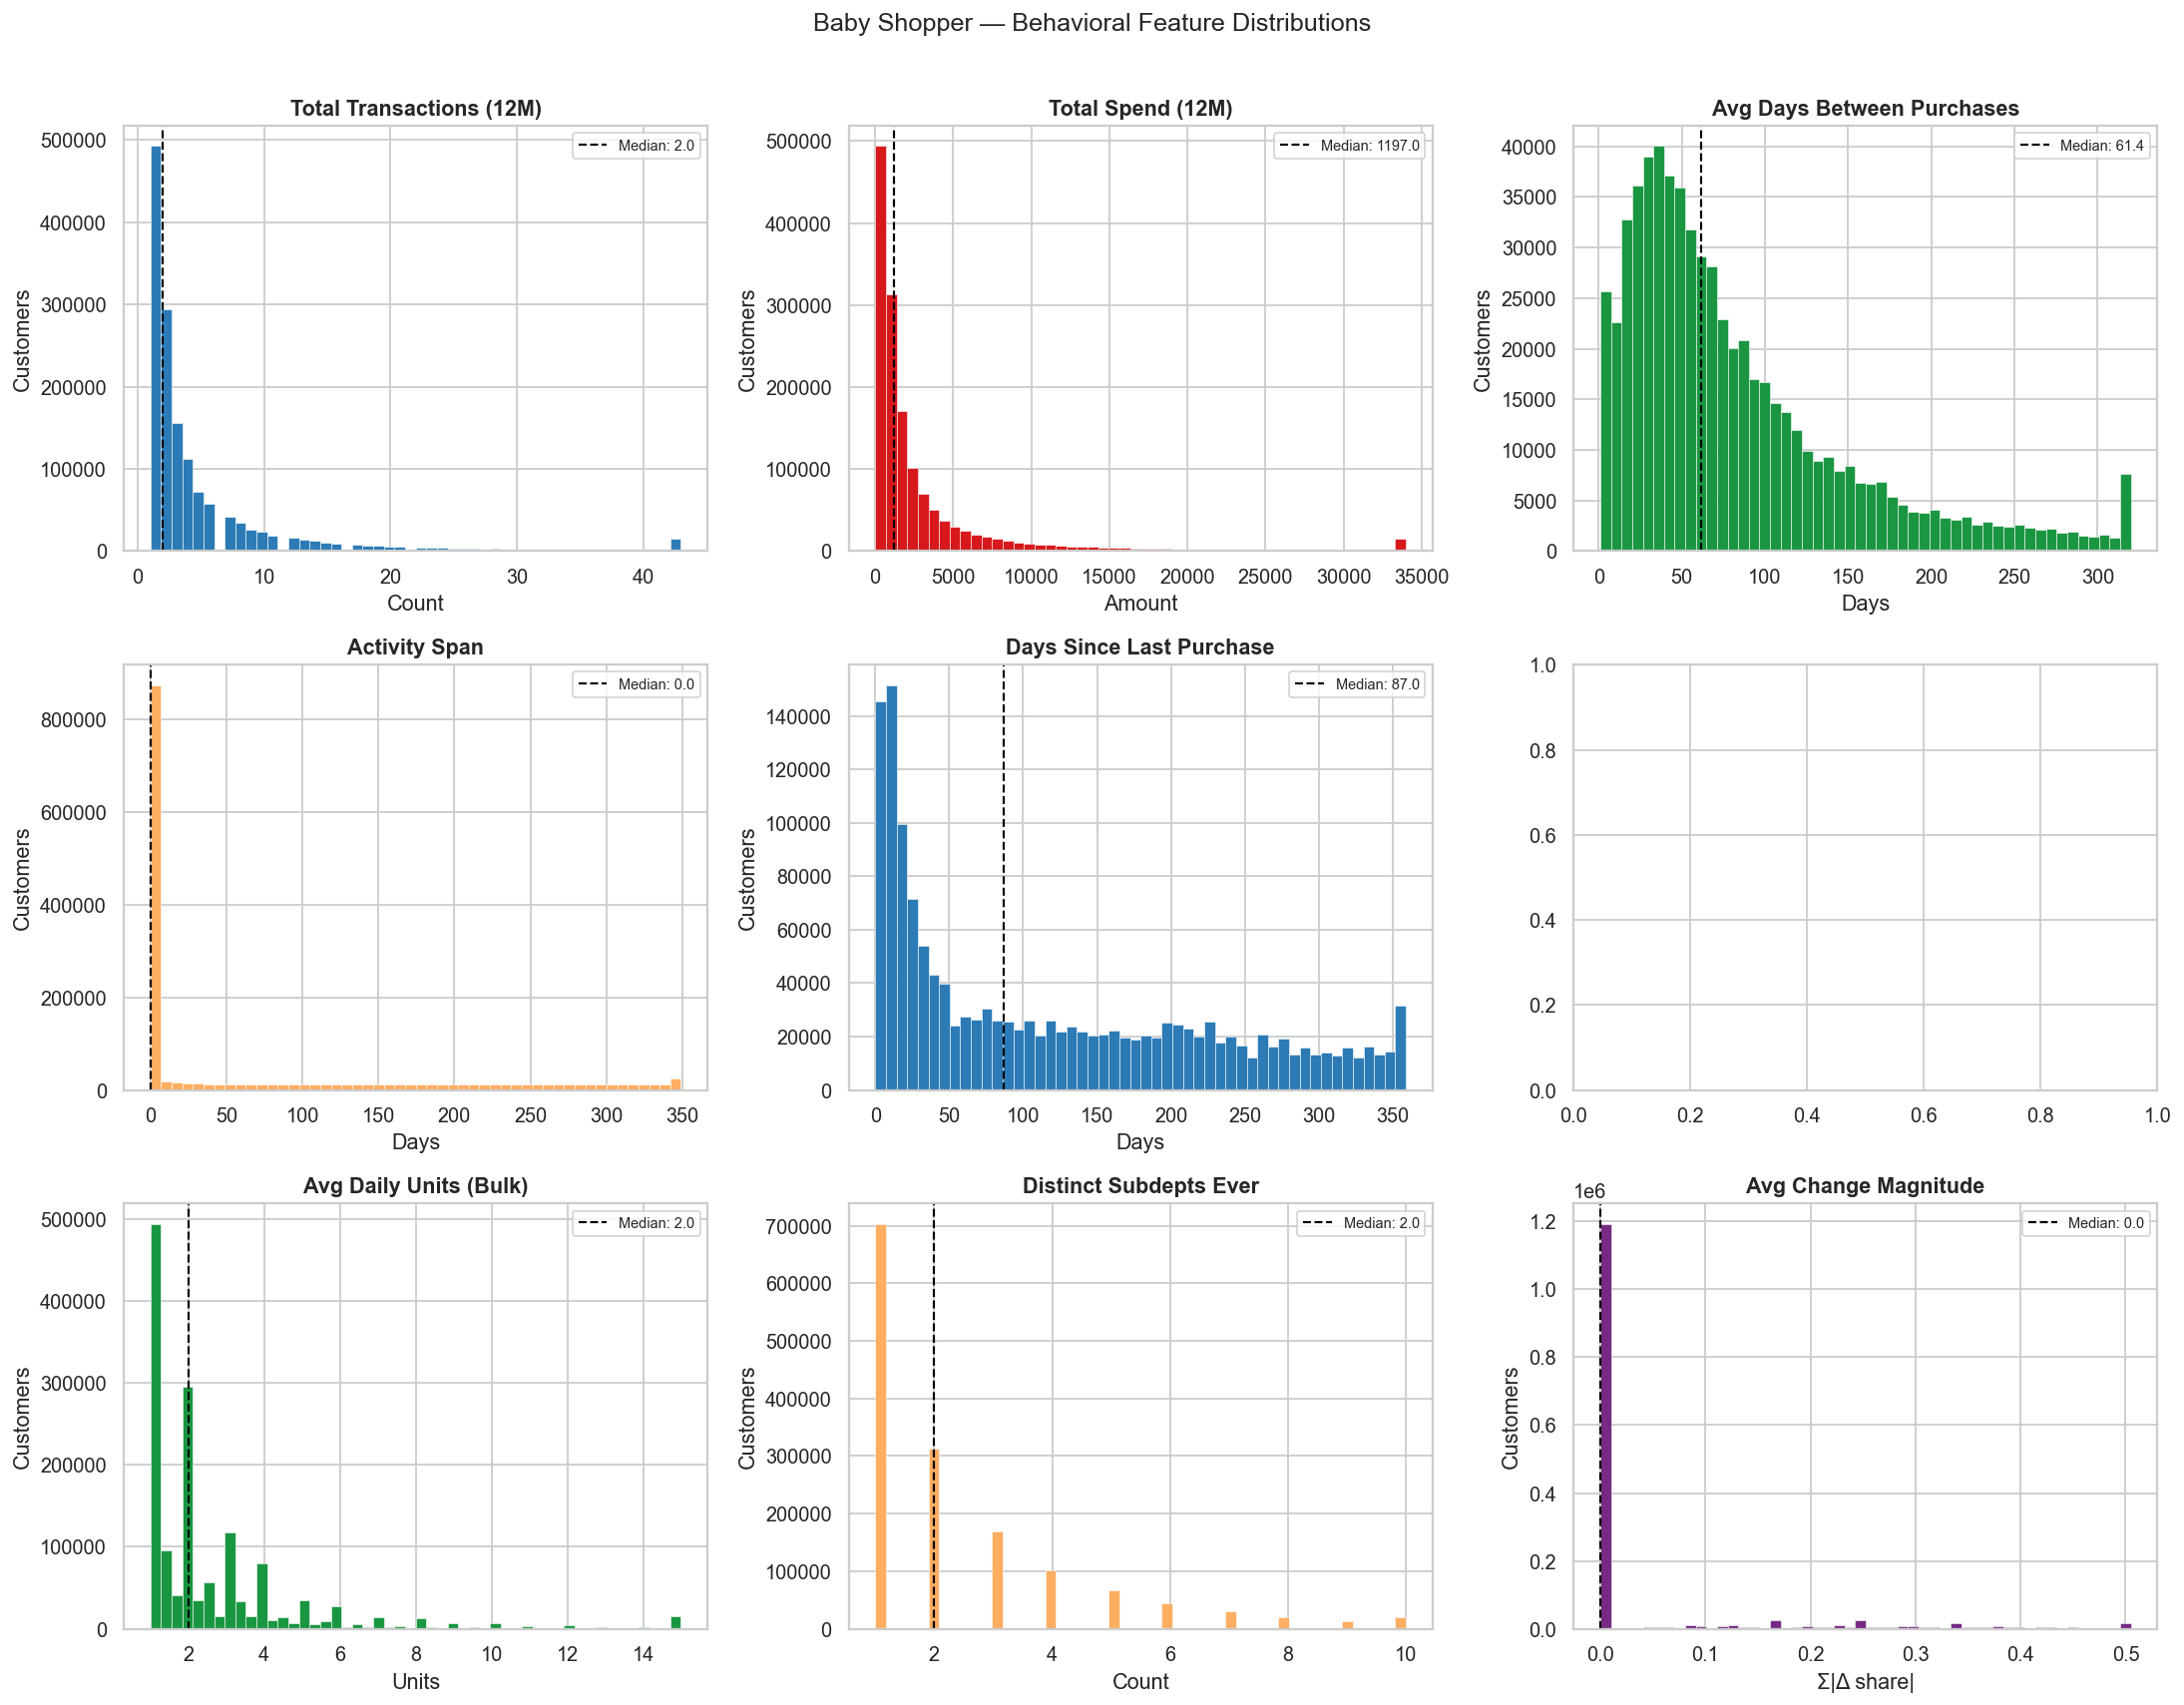

In [23]:
# ── 8.1 Core behavioral distributions ────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle('Baby Shopper — Behavioral Feature Distributions', fontsize=14, y=1.01)

def hist(ax, series, title, xlabel, color=PALETTE[0], pct=0.99):
    data = series.dropna()
    clip_val = data.quantile(pct)
    ax.hist(data.clip(upper=clip_val), bins=50, color=color,
            edgecolor='white', linewidth=0.3)
    med = data.median()
    ax.axvline(med, color='black', linestyle='--', lw=1.2,
               label=f'Median: {med:.1f}')
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('Customers')
    ax.legend(fontsize=8)

hist(axes[0,0], profile['total_transactions_12m'], 'Total Transactions (12M)', 'Count',       PALETTE[0])
hist(axes[0,1], profile['total_spend_12m'],        'Total Spend (12M)',        'Amount',       PALETTE[1])
hist(axes[0,2], profile['avg_gap_days'],           'Avg Days Between Purchases','Days',        PALETTE[2])
hist(axes[1,0], profile['activity_span_days'],     'Activity Span',            'Days',         PALETTE[3])
hist(axes[1,1], profile['days_since_last_purchase'],'Days Since Last Purchase', 'Days',        PALETTE[0])
# hist(axes[1,2], profile['lifecycle_signals'],       'Binge-Rest Ratio',         'Ratio',        PALETTE[1])
hist(axes[2,0], profile['bulk_score'],             'Avg Daily Units (Bulk)',   'Units',        PALETTE[2])
hist(axes[2,1], profile['distinct_subclass_count'], 'Distinct Subclasses Ever', 'Count',        PALETTE[3])
hist(axes[2,2], profile['avg_change_magnitude'],   'Avg Change Magnitude',     'Σ|Δ share|',   PALETTE[4])

plt.tight_layout()
plt.savefig('01_behavioral_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


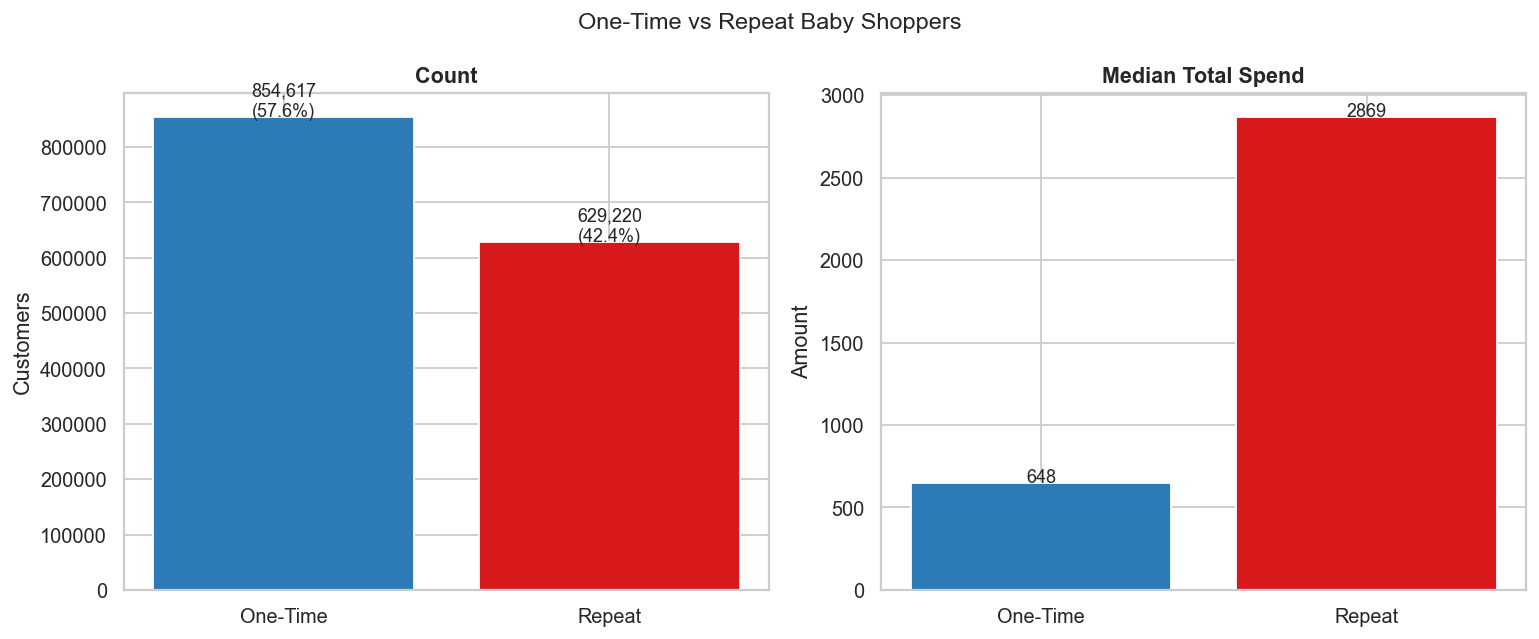

In [24]:
# ── 8.2 Shopper type: one-time vs repeat ─────────────────────────────────────
type_counts = profile['shopper_type'].value_counts()
type_spend  = profile.groupby('shopper_type')['total_spend_12m'].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('One-Time vs Repeat Baby Shoppers')

ax1.bar(type_counts.index, type_counts.values,
        color=[PALETTE[0], PALETTE[1]], edgecolor='white')
ax1.set_title('Count'); ax1.set_ylabel('Customers')
for i, (cat, val) in enumerate(type_counts.items()):
    ax1.text(i, val + 50, f'{val:,}\n({val/len(profile)*100:.1f}%)',
             ha='center', fontsize=10)

ax2.bar(type_spend.index, type_spend.values,
        color=[PALETTE[0], PALETTE[1]], edgecolor='white')
ax2.set_title('Median Total Spend'); ax2.set_ylabel('Amount')
for i, (cat, val) in enumerate(type_spend.items()):
    ax2.text(i, val + 1, f'{val:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('02_shopper_type.png', dpi=150, bbox_inches='tight')
plt.show()


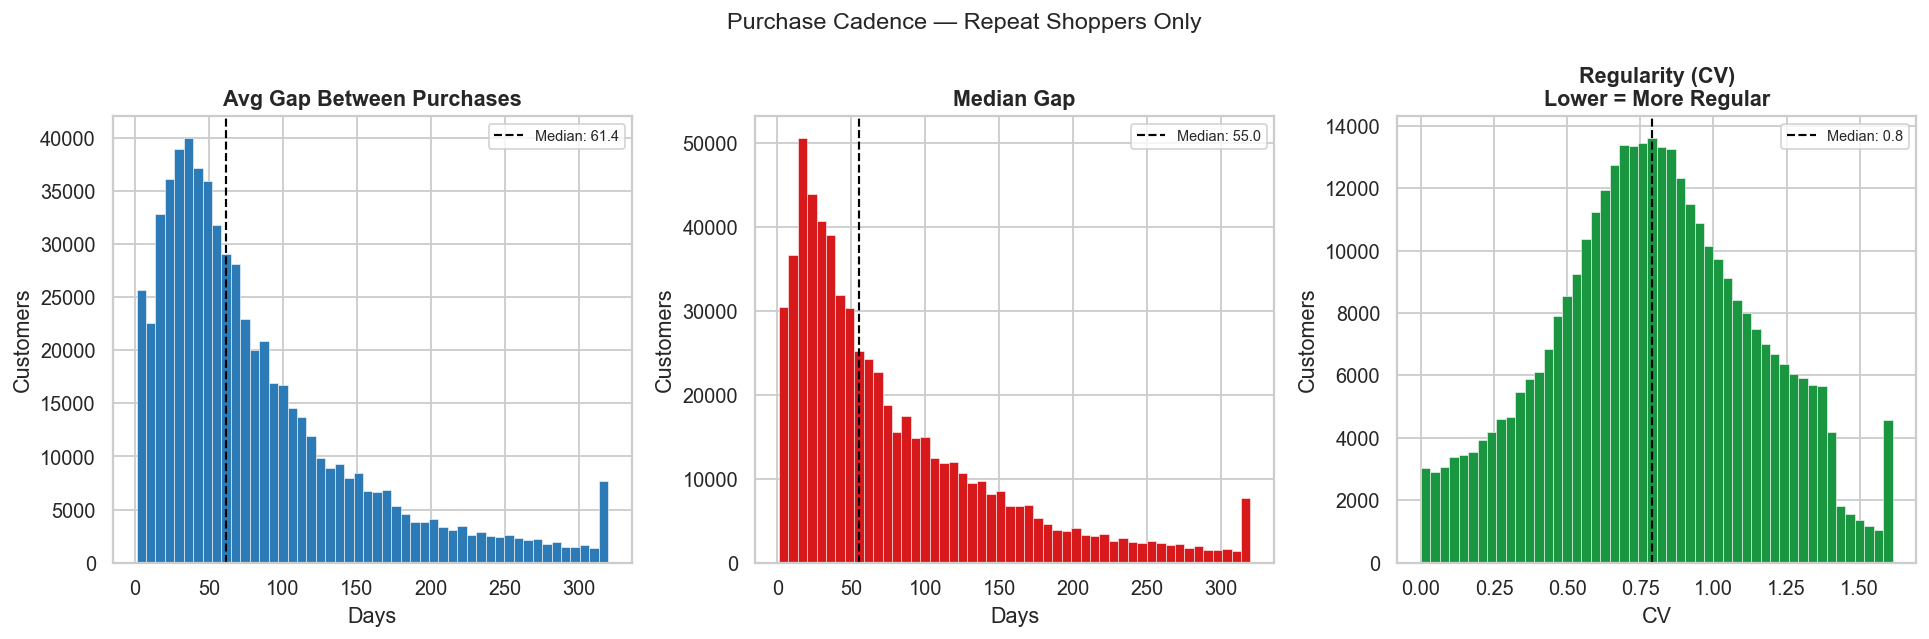

In [25]:
# ── 8.3 Purchase cadence distribution — repeat shoppers only ─────────────────
repeat = profile[profile['shopper_type'] == 'Repeat'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Purchase Cadence — Repeat Shoppers Only')

hist(axes[0], repeat['avg_gap_days'],    'Avg Gap Between Purchases', 'Days', PALETTE[0])
hist(axes[1], repeat['median_gap_days'], 'Median Gap',                'Days', PALETTE[1])
hist(axes[2], repeat['purchase_regularity_cv'], 'Regularity (CV)\nLower = More Regular',
     'CV', PALETTE[2])

plt.tight_layout()
plt.savefig('03_purchase_cadence.png', dpi=150, bbox_inches='tight')
plt.show()


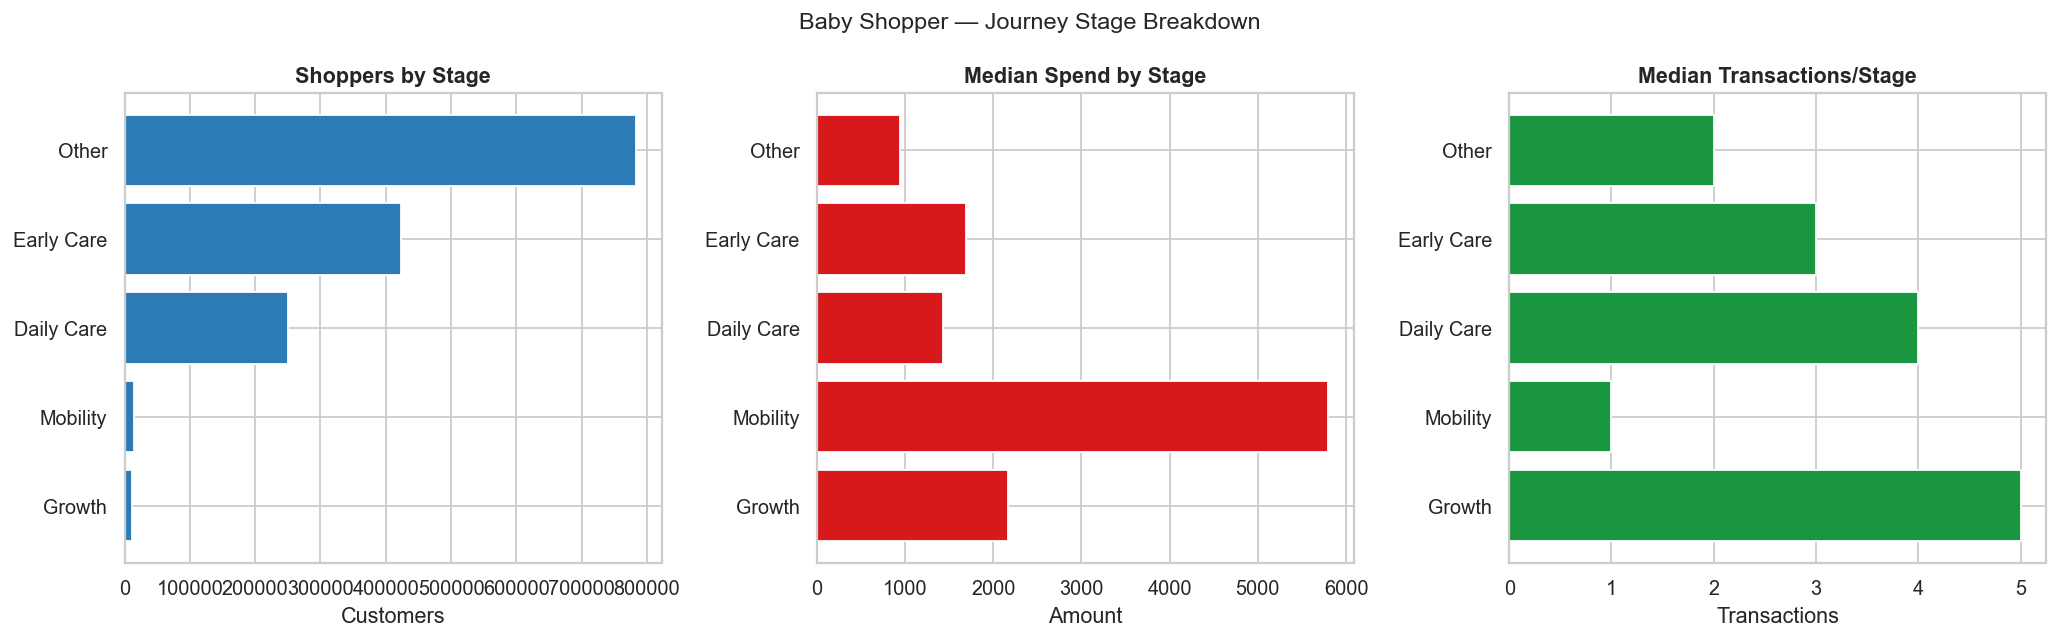

In [26]:
# ── 8.4 Journey stage distribution ───────────────────────────────────────────
stage_counts = profile['journey_stage'].value_counts()
stage_spend  = profile.groupby('journey_stage')['total_spend_12m'].median().reindex(stage_counts.index)
stage_freq   = profile.groupby('journey_stage')['total_transactions_12m'].median().reindex(stage_counts.index)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baby Shopper — Journey Stage Breakdown')

for ax, data, title, xlabel, color in [
    (axes[0], stage_counts,  'Shoppers by Stage',        'Customers',     PALETTE[0]),
    (axes[1], stage_spend,   'Median Spend by Stage',    'Amount',        PALETTE[1]),
    (axes[2], stage_freq,    'Median Transactions/Stage','Transactions',  PALETTE[2]),
]:
    ax.barh(data.index, data.values, color=color, edgecolor='white')
    ax.set_title(title); ax.set_xlabel(xlabel)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('04_journey_stages.png', dpi=150, bbox_inches='tight')
plt.show()


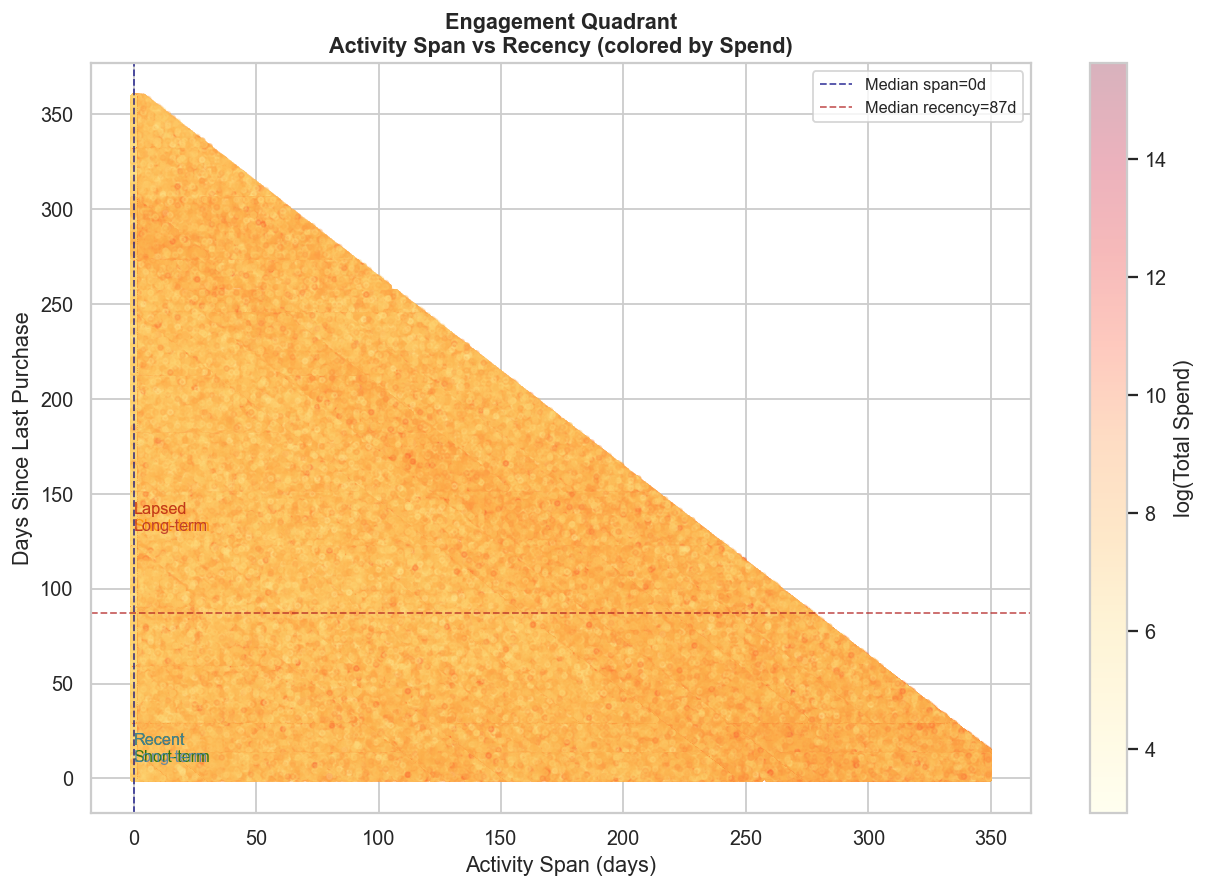

In [27]:
# ── 8.5 Activity span vs recency — engagement quadrant ───────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

span_clip    = profile['activity_span_days'].clip(upper=profile['activity_span_days'].quantile(0.99))
recency_clip = profile['days_since_last_purchase'].clip(upper=profile['days_since_last_purchase'].quantile(0.99))

sc = ax.scatter(
    span_clip, recency_clip,
    c=np.log1p(profile['total_spend_12m']),
    cmap='YlOrRd', alpha=0.3, s=8
)
plt.colorbar(sc, label='log(Total Spend)')

span_med    = span_clip.median()
recency_med = recency_clip.median()
ax.axvline(span_med,    color='navy',  linestyle='--', lw=1, alpha=0.7, label=f'Median span={span_med:.0f}d')
ax.axhline(recency_med, color='firebrick', linestyle='--', lw=1, alpha=0.7, label=f'Median recency={recency_med:.0f}d')

ax.set_title('Engagement Quadrant\nActivity Span vs Recency (colored by Spend)', fontweight='bold')
ax.set_xlabel('Activity Span (days)'); ax.set_ylabel('Days Since Last Purchase')
ax.legend(fontsize=9)

# Quadrant labels
ax.text(span_med*0.1,    recency_med*0.1,  'Recent\nShort-term',   fontsize=9, color='darkgreen',  alpha=0.8)
ax.text(span_med*1.5,    recency_med*0.1,  'Recent\nLong-term',    fontsize=9, color='steelblue',  alpha=0.8)
ax.text(span_med*0.1,    recency_med*1.5,  'Lapsed\nShort-term',   fontsize=9, color='darkorange', alpha=0.8)
ax.text(span_med*1.5,    recency_med*1.5,  'Lapsed\nLong-term',    fontsize=9, color='firebrick',  alpha=0.8)

plt.tight_layout()
plt.savefig('05_engagement_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()


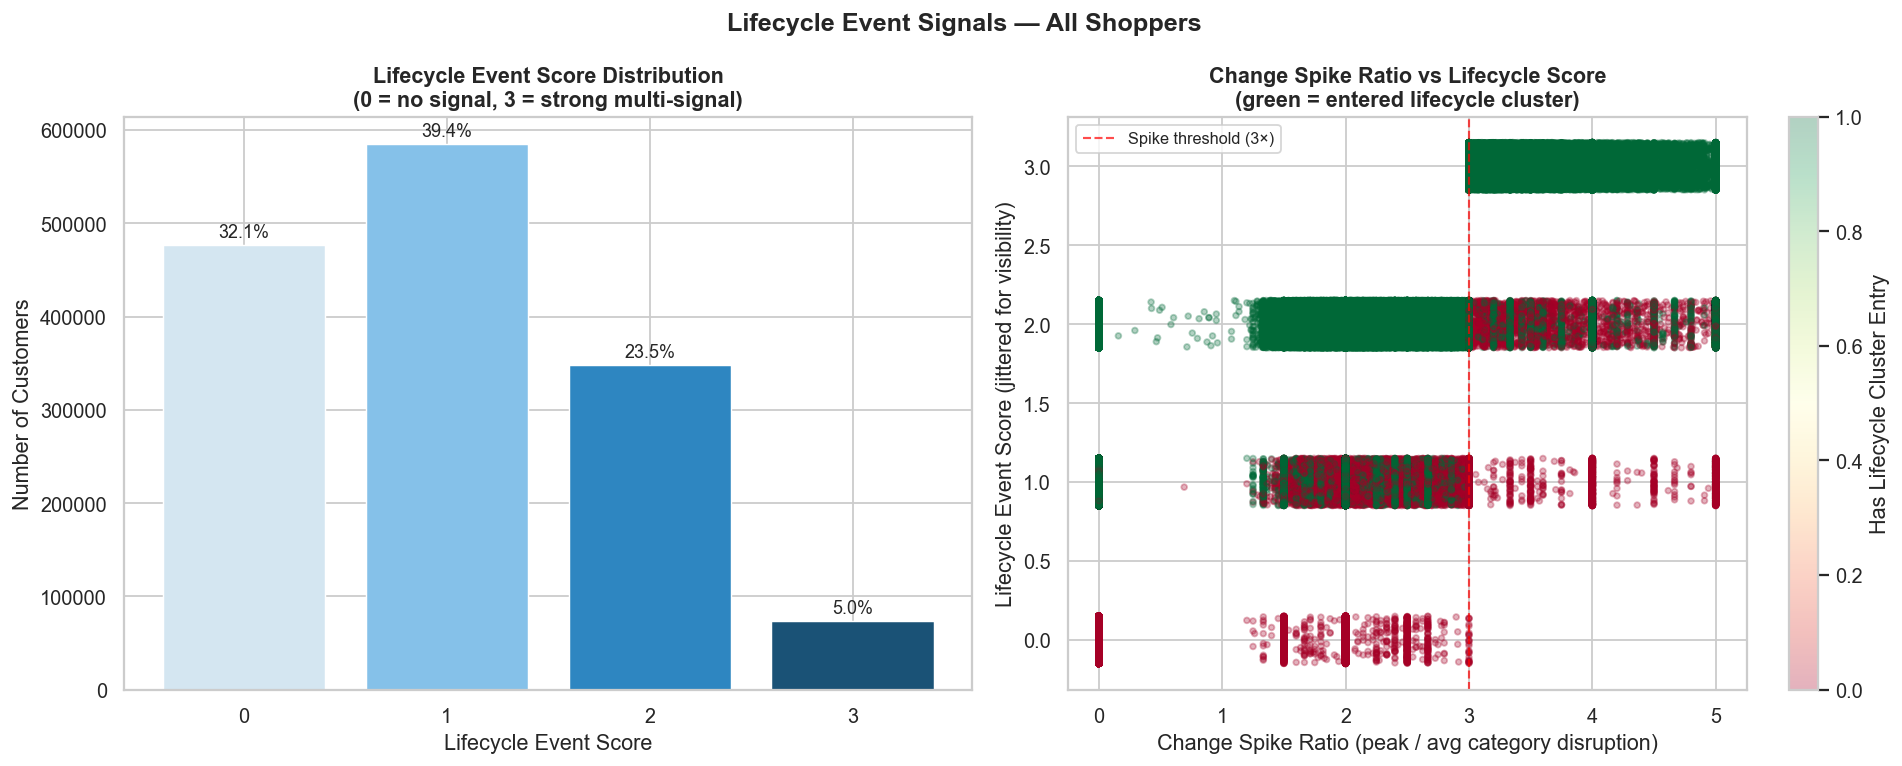

Saved: 06_lifecycle_event_signals.png


In [28]:
# ── 8.6 Lifecycle Event Signals — distribution & scatter ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax1, ax2 = axes
fig.suptitle('Lifecycle Event Signals — All Shoppers', fontweight='bold', fontsize=14)

# Left: Lifecycle event score distribution
score_counts = profile['lifecycle_event_score'].value_counts().sort_index()
bar_colors = ['#d4e6f1', '#85c1e9', '#2e86c1', '#1a5276'][:len(score_counts)]
bars = ax1.bar(score_counts.index.astype(str), score_counts.values,
               color=bar_colors, edgecolor='white', linewidth=0.8)
ax1.set_title('Lifecycle Event Score Distribution\n(0 = no signal, 3 = strong multi-signal)',
              fontweight='bold')
ax1.set_xlabel('Lifecycle Event Score')
ax1.set_ylabel('Number of Customers')
for bar, val in zip(bars, score_counts.values):
    pct = val / len(profile) * 100
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + len(profile) * 0.003,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

# Right: Change spike ratio vs lifecycle score (repeat shoppers)
if 'change_spike_ratio' in profile.columns and profile['change_spike_ratio'].notna().any():
    lc_repeat = repeat[
        repeat['lifecycle_event_score'].notna() &
        repeat['change_spike_ratio'].notna()
    ].copy()
    if len(lc_repeat) > 0:
        spike_clip = lc_repeat['change_spike_ratio'].clip(
            upper=lc_repeat['change_spike_ratio'].quantile(0.99)
        )
        sc = ax2.scatter(
            spike_clip,
            lc_repeat['lifecycle_event_score'] + np.random.uniform(-0.15, 0.15, len(lc_repeat)),
            c=lc_repeat['has_lifecycle_entry'],
            cmap='RdYlGn', alpha=0.3, s=10, vmin=0, vmax=1
        )
        plt.colorbar(sc, ax=ax2, label='Has Lifecycle Cluster Entry')
        ax2.set_title('Change Spike Ratio vs Lifecycle Score\n(green = entered lifecycle cluster)',
                      fontweight='bold')
        ax2.set_xlabel('Change Spike Ratio (peak / avg category disruption)')
        ax2.set_ylabel('Lifecycle Event Score (jittered for visibility)')
        ax2.axvline(3.0, color='red', linestyle='--', lw=1.2, alpha=0.7, label='Spike threshold (3×)')
        ax2.legend(fontsize=9)
    else:
        ax2.set_title('No repeat shoppers with spike data', fontweight='bold')
        ax2.axis('off')
else:
    # Fallback: show lifecycle entry rate by score instead
    entry_by_score = profile.groupby('lifecycle_event_score')['has_lifecycle_entry'].mean() * 100
    ax2.bar(entry_by_score.index.astype(str), entry_by_score.values, color='#2e86c1', edgecolor='white')
    ax2.set_title('Lifecycle Entry Rate by Score\n(change_spike_ratio unavailable)',
                  fontweight='bold')
    ax2.set_xlabel('Lifecycle Event Score')
    ax2.set_ylabel('% with Lifecycle Cluster Entry')

plt.tight_layout()
plt.savefig('06_lifecycle_event_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_lifecycle_event_signals.png")

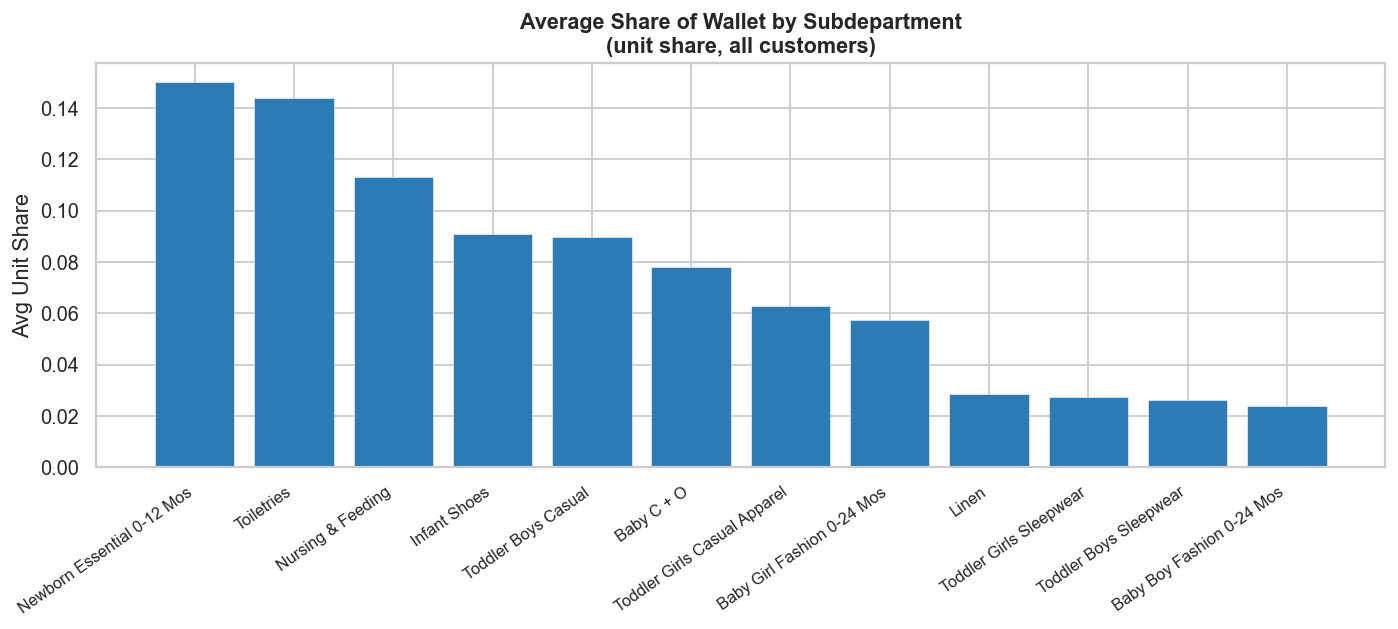

In [29]:
# ── 8.7 Category share of wallet — top subclasses ───────────────────────────────
sow_cols = [c for c in profile.columns if c.startswith('scl__')]
sow_means = (
    profile[sow_cols].mean()
                     .sort_values(ascending=False)
                     .head(12)
)
sow_means.index = [c.replace('scl__','').replace('_',' ').title() for c in sow_means.index]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(sow_means.index, sow_means.values,
       color=PALETTE[0], edgecolor='white', linewidth=0.3)
ax.set_title('Average Share of Wallet by Subclass\n(unit share, all customers)', fontweight='bold')
ax.set_ylabel('Avg Unit Share')
ax.set_xticklabels(sow_means.index, rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('07_share_of_wallet.png', dpi=150, bbox_inches='tight')
plt.show()


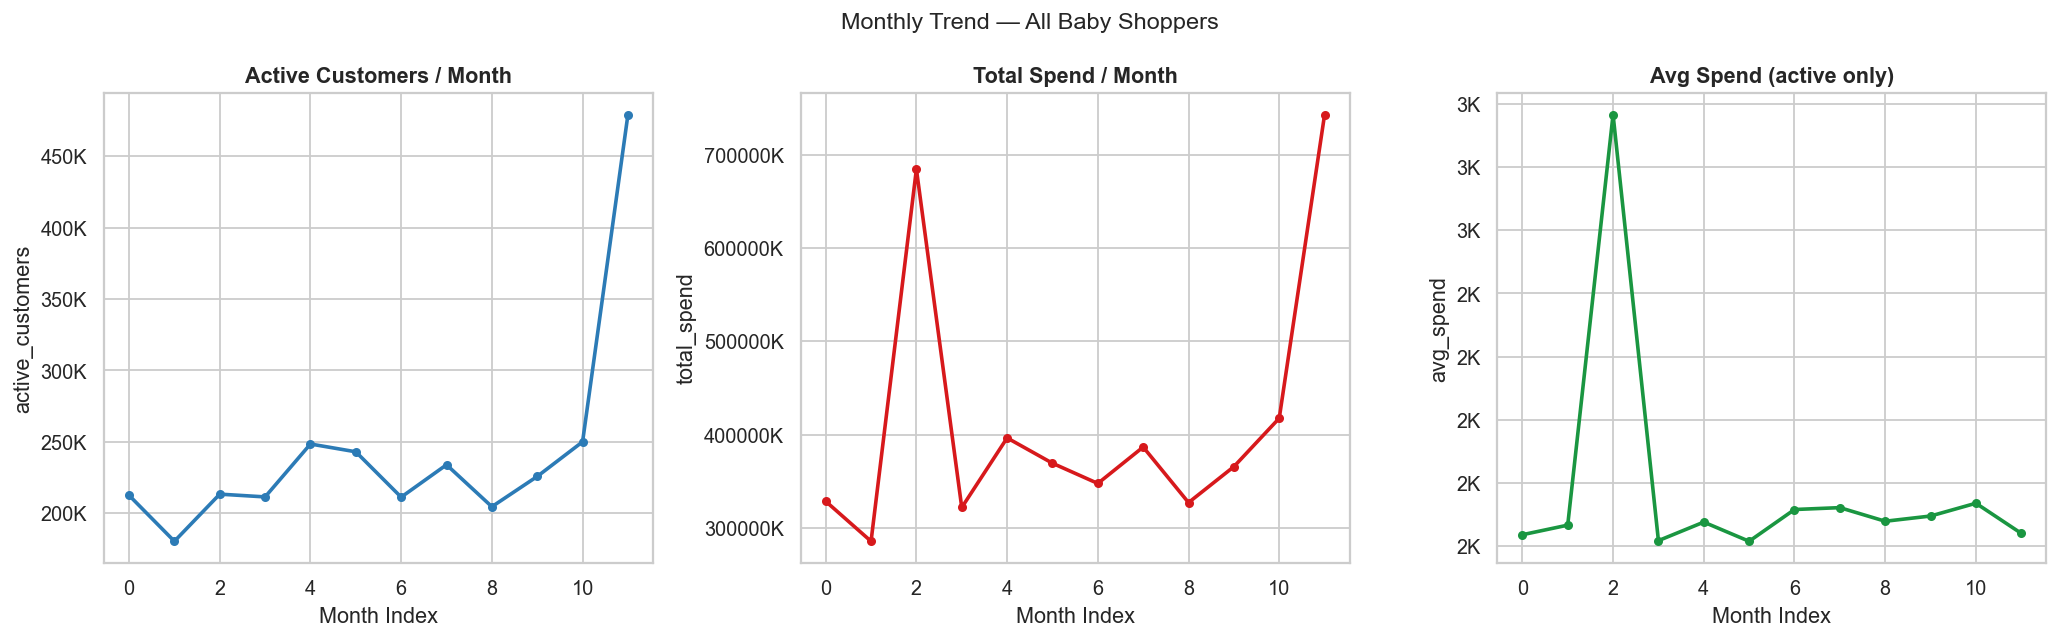

In [30]:
# ── 8.8 Monthly panel trends ─────────────────────────────────────────────────
# avg spend on active months only: pre-filter, then merge
active_panel = panel[panel['is_active'] == 1]
avg_spend_monthly = (
    active_panel.groupby('year_month')['total_spend']
                .mean()
                .rename('avg_spend')
                .reset_index()
)
panel_monthly = (
    panel.groupby('year_month')
         .agg(
             active_customers = ('is_active',    'sum'),
             total_spend      = ('total_spend',  'sum'),
         )
         .reset_index()
         .merge(avg_spend_monthly, on='year_month', how='left')
)
months_idx = range(len(panel_monthly))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Monthly Trend — All Baby Shoppers')

def fmt_k(x, _):
    return f'{x/1e3:.0f}K' if x >= 1000 else f'{x:.0f}'

for ax, col, title, color in [
    (axes[0], 'active_customers', 'Active Customers / Month', PALETTE[0]),
    (axes[1], 'total_spend',      'Total Spend / Month',      PALETTE[1]),
    (axes[2], 'avg_spend',        'Avg Spend (active only)',  PALETTE[2]),
]:
    ax.plot(months_idx, panel_monthly[col], 'o-', color=color, linewidth=2, markersize=4)
    ax.set_title(title); ax.set_xlabel('Month Index'); ax.set_ylabel(col)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

plt.tight_layout()
plt.savefig('08_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Behavioral Clustering

Grouping shoppers by **how they shop**, not what they buy.

Clustering features are drawn directly from the spec's behavioral dimensions:
frequency, cadence, span, burst, bulk, breadth, recency, and spend.


In [31]:
# ── 9.1 Define clustering features ───────────────────────────────────────────
CLUSTER_FEATURES = [
    'total_transactions_12m',  # frequency
    'total_spend_12m',         # spend level
    'avg_gap_days',            # purchase cadence
    'activity_span_days',      # engagement duration
    'days_since_last_purchase',# recency
    'lifecycle_event_score',   # composite lifecycle signal (0-3)
    'change_spike_ratio',      # peak category disruption vs avg
    'has_lifecycle_entry',     # entered a lifecycle cluster
    'bulk_score',              # bulk purchasing
    'distinct_subclass_count',  # category breadth
    'purchase_regularity_cv',  # regular vs erratic
    'engagement_density',      # active months / possible months
]

cluster_df = profile[['customer_id','shopper_type'] + CLUSTER_FEATURES].dropna(
    subset=CLUSTER_FEATURES
).copy()

# Clip outliers (p1–p99) before scaling
for col in CLUSTER_FEATURES:
    lo, hi = cluster_df[col].quantile([0.01, 0.99])
    cluster_df[col] = cluster_df[col].clip(lo, hi)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[CLUSTER_FEATURES])
print(f"Clustering dataset: {cluster_df.shape[0]:,} customers, {len(CLUSTER_FEATURES)} features")

Clustering dataset: 360,188 customers, 12 features


  k=2  inertia=3,321,999  silhouette=0.2197
  k=3  inertia=2,841,920  silhouette=0.1863
  k=4  inertia=2,511,985  silhouette=0.1876
  k=5  inertia=2,233,603  silhouette=0.1939
  k=6  inertia=2,082,879  silhouette=0.1982
  k=7  inertia=1,949,028  silhouette=0.1795
  k=8  inertia=1,844,900  silhouette=0.1768


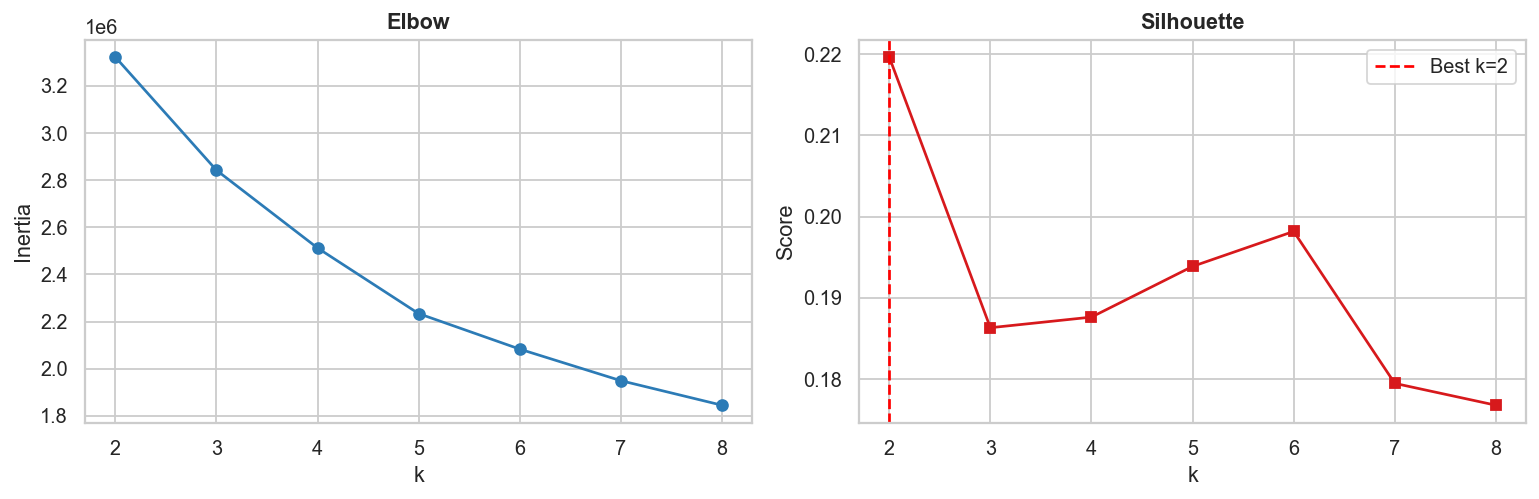


Statistically optimal k = 2


In [32]:
# ── 9.2 Optimal k — elbow + silhouette ───────────────────────────────────────
K_RANGE      = range(2, 9)
inertias     = []
silhouettes  = []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, lbl, sample_size=min(5000, len(X_scaled)),
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

best_k = list(K_RANGE)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias,    'o-', color=PALETTE[0]); ax1.set_title('Elbow'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax2.plot(list(K_RANGE), silhouettes, 's-', color=PALETTE[1]); ax2.set_title('Silhouette'); ax2.set_xlabel('k'); ax2.set_ylabel('Score')
ax2.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}'); ax2.legend()
plt.tight_layout()
plt.savefig('09_cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nStatistically optimal k = {best_k}")


In [33]:
# ── 9.3 Fit final model ───────────────────────────────────────────────────────
# Set K_FINAL = best_k, or override if a different k tells a clearer story
K_FINAL  = best_k

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)
profile = profile.merge(cluster_df[['customer_id','cluster']], on='customer_id', how='left')

print("Cluster distribution:")
print(profile['cluster'].value_counts().sort_index())


Cluster distribution:
cluster
0.000    132713
1.000    227475
Name: count, dtype: int64


In [34]:
# ── 9.4 Cluster centroids ─────────────────────────────────────────────────────
centroids = (
    profile.dropna(subset=['cluster'])
           .groupby('cluster')[CLUSTER_FEATURES]
           .median()
)
centroids['n']   = profile['cluster'].value_counts().sort_index()
centroids['pct'] = (centroids['n'] / len(profile) * 100).round(1)

print("=== Cluster Centroids (median) ===")
centroids.T


=== Cluster Centroids (median) ===


cluster,0.000,1.000
total_transactions_12m,20.000,6.000
total_spend_12m,11727.000,2971.000
avg_gap_days,38.333,66.500
activity_span_days,290.000,194.000
days_since_last_purchase,17.000,39.000
lifecycle_event_score,2.000,2.000
change_spike_ratio,2.698,1.474
has_lifecycle_entry,1.000,1.000
bulk_score,3.444,2.000
distinct_subdept_count,7.000,3.000


In [35]:
# ── 9.5 Auto-name clusters from centroid profile ─────────────────────────────
CLUSTER_NAMES = {}

for c in sorted(profile['cluster'].dropna().unique()):
    c = int(c)
    freq      = centroids.loc[c, 'total_transactions_12m']
    recency   = centroids.loc[c, 'days_since_last_purchase']
    lc_score  = centroids.loc[c, 'lifecycle_event_score']
    lc_entry  = centroids.loc[c, 'has_lifecycle_entry']
    spike     = centroids.loc[c, 'change_spike_ratio']
    bulk      = centroids.loc[c, 'bulk_score']
    density   = centroids.loc[c, 'engagement_density']
    gap       = centroids.loc[c, 'avg_gap_days']

    med_freq    = centroids['total_transactions_12m'].median()
    med_recency = centroids['days_since_last_purchase'].median()
    med_lc      = centroids['lifecycle_event_score'].median()
    med_spike   = centroids['change_spike_ratio'].median()
    med_bulk    = centroids['bulk_score'].median()
    med_density = centroids['engagement_density'].median()

    if recency > med_recency * 1.5:
        name = 'Lapsed Shoppers'
    elif freq <= 1:
        name = 'One-and-Done'
    elif lc_score >= 2 and spike > med_spike * 1.5:
        name = 'Lifecycle Event Shoppers'       # strong multi-signal lifecycle trigger
    elif lc_score >= 1 and lc_entry == 1:
        name = 'New Category Entrants'           # entered a lifecycle cluster significantly
    elif lc_score >= 1 and bulk > med_bulk * 1.3:
        name = 'Event-Driven Stockpilers'        # lifecycle signal + bulk buying
    elif freq > med_freq * 1.3 and gap < centroids['avg_gap_days'].median():
        name = 'High-Frequency Regulars'
    elif density > med_density:
        name = 'Consistent Engagers'
    else:
        name = 'Moderate Buyers'

    CLUSTER_NAMES[c] = name
    print(f"Cluster {c} ({centroids.loc[c,'pct']:.1f}%) → '{name}'")

# ── Assign segment labels to profile ─────────────────────────────────────────
profile['segment'] = (
    profile['cluster']
    .map(CLUSTER_NAMES)
    .fillna('Unassigned')
)

print("\nSegment distribution:")
print(profile['segment'].value_counts())


Cluster 0 (8.9%) → 'New Category Entrants'
Cluster 1 (15.3%) → 'New Category Entrants'

Segment distribution:
segment
Unassigned               1123649
New Category Entrants     360188
Name: count, dtype: int64


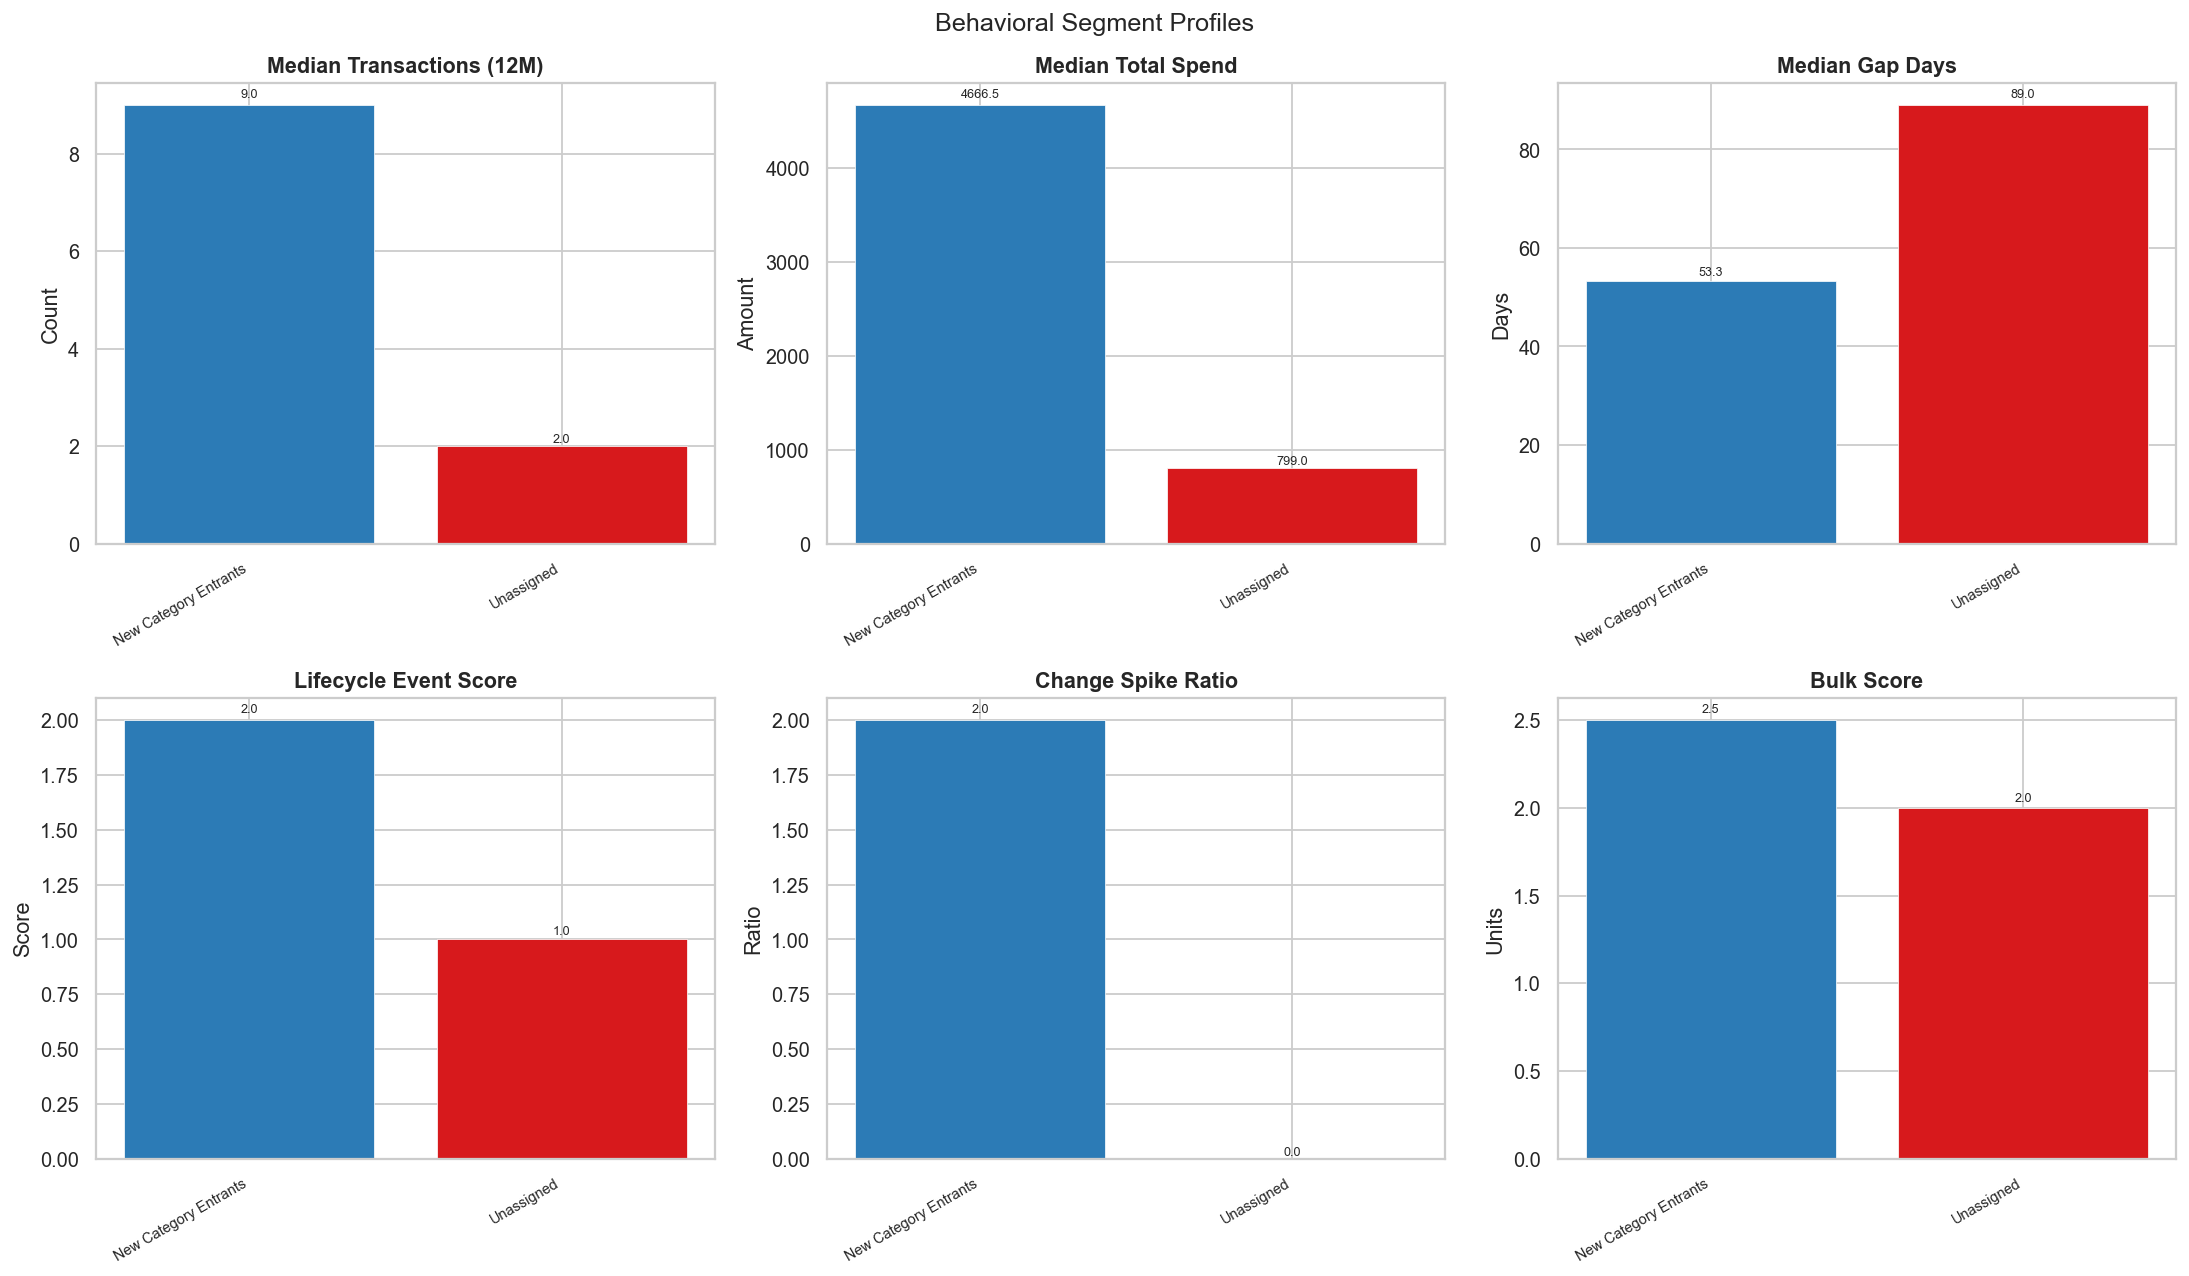

In [36]:
# ── 9.6 Segment comparison — bar charts ──────────────────────────────────────
seg_order = (
    profile.groupby('segment')['total_transactions_12m']
           .median().sort_values(ascending=False).index.tolist()
)

metrics = [
    ('total_transactions_12m',  'Median Transactions (12M)',   'Count'),
    ('total_spend_12m',         'Median Total Spend',          'Amount'),
    ('avg_gap_days',            'Median Gap Days',             'Days'),
    ('lifecycle_event_score',   'Lifecycle Event Score',       'Score'),
    ('change_spike_ratio',      'Change Spike Ratio',          'Ratio'),
    ('bulk_score',              'Bulk Score',                  'Units'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Behavioral Segment Profiles', fontsize=14)

for ax, (col, title, ylabel) in zip(axes.flatten(), metrics):
    vals = profile.groupby('segment')[col].median().reindex(seg_order)
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(vals))]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('10_segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

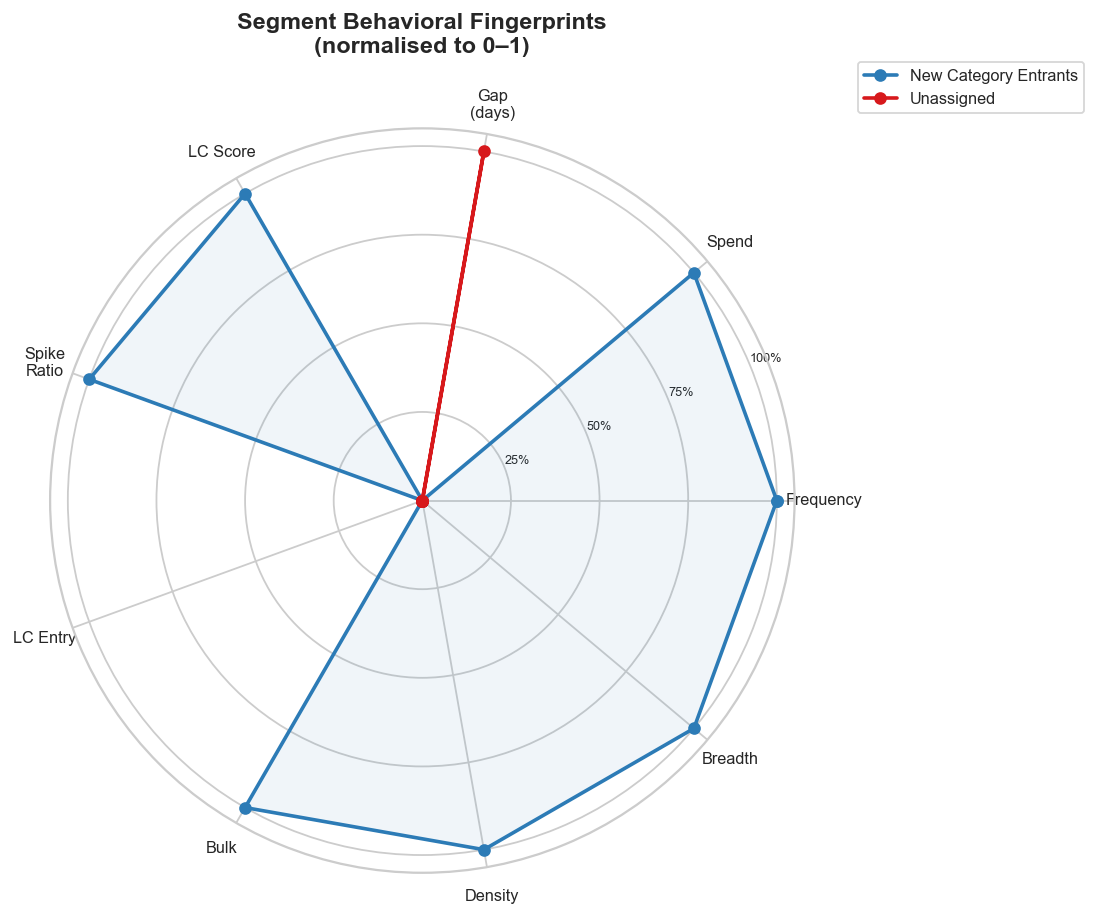

In [37]:
# ── 9.7 Radar chart — segment behavioral fingerprints ────────────────────────
radar_features = [
    'total_transactions_12m', 'total_spend_12m', 'avg_gap_days',
    'lifecycle_event_score', 'change_spike_ratio', 'has_lifecycle_entry',
    'bulk_score', 'engagement_density', 'distinct_subclass_count'
]
radar_labels = [
    'Frequency', 'Spend', 'Gap\n(days)',
    'LC Score', 'Spike\nRatio', 'LC Entry',
    'Bulk', 'Density', 'Breadth'
]

seg_radar = (
    profile.dropna(subset=['segment'])
           .groupby('segment')[radar_features].median()
)
seg_norm = (seg_radar - seg_radar.min()) / (seg_radar.max() - seg_radar.min() + 1e-9)

N      = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, (seg, row) in enumerate(seg_norm.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    color = PALETTE[i % len(PALETTE)]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=seg)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7)
ax.set_title('Segment Behavioral Fingerprints\n(normalised to 0–1)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('11_segment_radar.png', dpi=150, bbox_inches='tight')
plt.show()

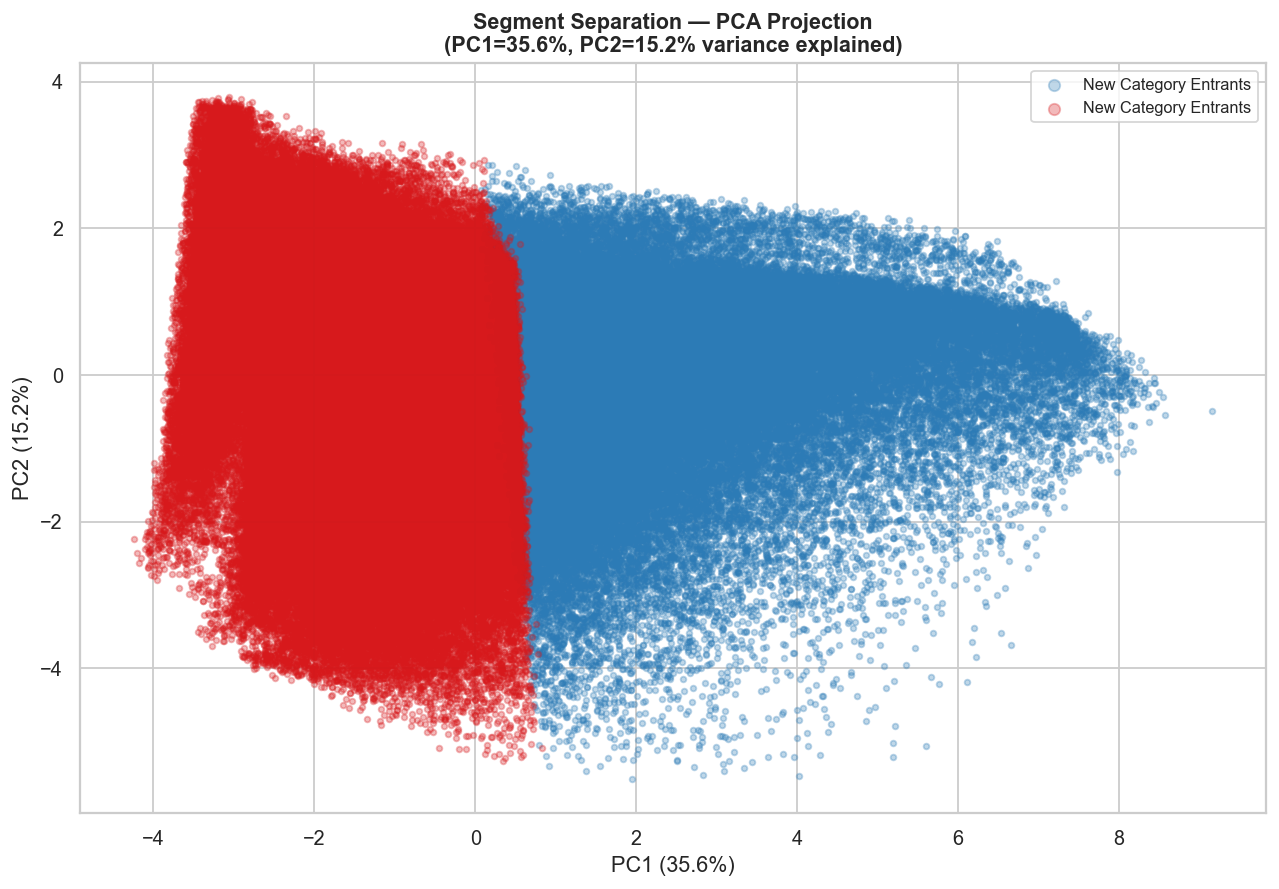

In [38]:
# ── 9.8 PCA scatter — cluster separation ─────────────────────────────────────
pca     = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca   = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

pca_df = cluster_df[['customer_id','cluster']].copy()
pca_df['pc1'] = X_pca[:, 0]
pca_df['pc2'] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(pca_df['cluster'].unique()):
    mask = pca_df['cluster'] == c
    ax.scatter(pca_df.loc[mask,'pc1'], pca_df.loc[mask,'pc2'],
               label=CLUSTER_NAMES.get(int(c), f'Cluster {c}'),
               alpha=0.3, s=10, color=PALETTE[int(c) % len(PALETTE)])

ax.set_title(
    f"Segment Separation — PCA Projection\n"
    f"(PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}% variance explained)",
    fontweight='bold'
)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.savefig('12_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Category Transition Signals
*(Descriptive only — prediction is Phase 2)*

How do baby shoppers move between subclasss over time?  
This transition view is the direct input for Phase 2 lifecycle modeling.


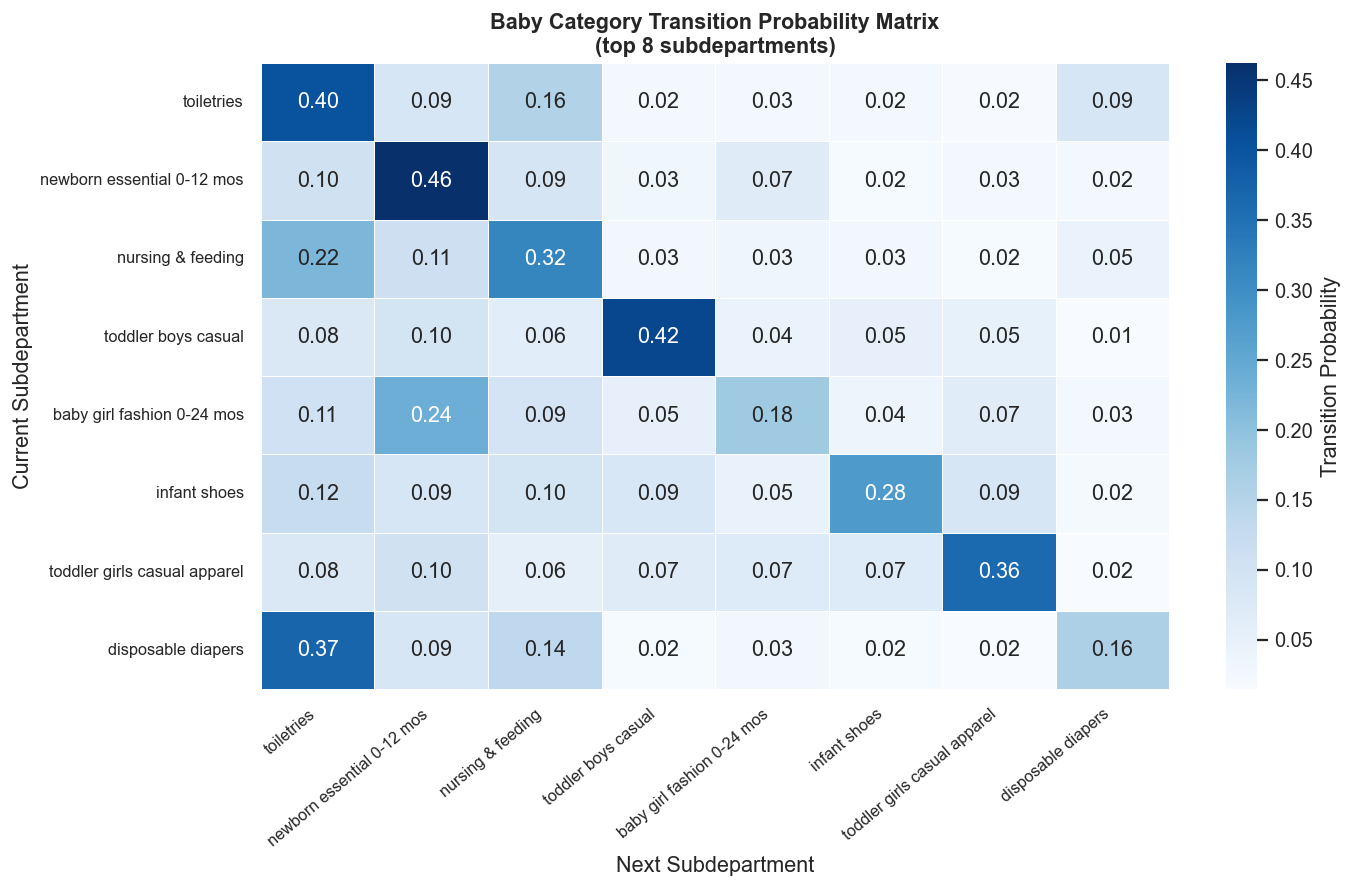

In [39]:
# ── 10.1 Transition probability matrix ────────────────────────────────────────
df_sorted = df.sort_values(['customer_id', 'date'])
df_sorted['next_subclass'] = df_sorted.groupby('customer_id')['subclass'].shift(-1)

transitions = (
    df_sorted.dropna(subset=['next_subclass'])
             .groupby(['subclass', 'next_subclass'])
             .size()
             .reset_index(name='count')
)
# Probability = count / row total per from-subdept — vectorised divide
from_totals = transitions.groupby('subclass')['count'].sum().rename('from_total')
transitions = transitions.join(from_totals, on='subclass')
transitions['prob'] = transitions['count'] / transitions['from_total']
transitions = transitions.drop(columns='from_total')

top_subclasses = df['subclass'].value_counts().head(8).index.tolist()
hm_data = (
    transitions[
        transitions['subclass'].isin(top_subclasses) &
        transitions['next_subclass'].isin(top_subclasses)
    ]
    .pivot(index='subclass', columns='next_subclass', values='prob')
    .fillna(0)
    .reindex(index=top_subclasses, columns=top_subclasses, fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(hm_data, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Transition Probability'})
ax.set_title('Baby Subclass Transition Probability Matrix\n(top 12 subclasses)',
             fontweight='bold')
ax.set_xlabel('Next Subclass'); ax.set_ylabel('Current Subclass')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('13_transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


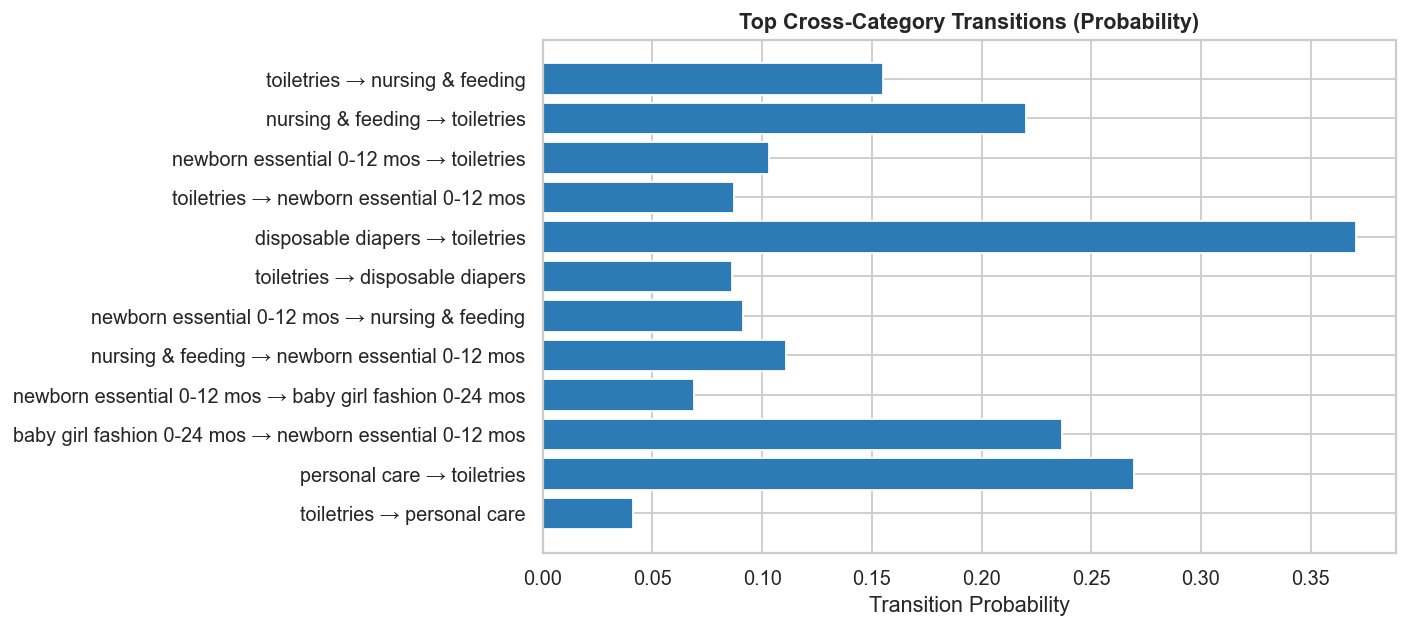

In [40]:
# ── 10.2 Top cross-category transitions ──────────────────────────────────────
cross = (
    transitions[transitions['subclass'] != transitions['next_subclass']]
    .sort_values('count', ascending=False).head(12)
)
cross['label'] = cross['subclass'] + ' → ' + cross['next_subclass']

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(cross['label'], cross['prob'], color=PALETTE[0], edgecolor='white')
ax.set_title('Top Cross-Category Transitions (Probability)', fontweight='bold')
ax.set_xlabel('Transition Probability'); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('14_top_transitions.png', dpi=150, bbox_inches='tight')
plt.show()


In [41]:
# ── 10.3 Transition patterns by segment ──────────────────────────────────────
df_seg = df.merge(profile[['customer_id', 'segment']], on='customer_id', how='left')
df_seg = df_seg.sort_values(['customer_id', 'date'])
df_seg['next_subclass'] = df_seg.groupby('customer_id')['subclass'].shift(-1)

seg_transitions = (
    df_seg.dropna(subset=['next_subclass', 'segment'])
          .groupby(['segment', 'subclass', 'next_subclass'])
          .size()
          .reset_index(name='count')
)

# Vectorised probability: join group totals then divide
seg_from_totals = (
    seg_transitions.groupby(['segment', 'subclass'])['count']
                   .sum()
                   .rename('from_total')
                   .reset_index()
)
seg_transitions = seg_transitions.merge(seg_from_totals, on=['segment', 'subclass'])
seg_transitions['prob'] = seg_transitions['count'] / seg_transitions['from_total']
seg_transitions = seg_transitions.drop(columns='from_total')

# Top cross-category exit per segment × subdept
top_exits = (
    seg_transitions[seg_transitions['subclass'] != seg_transitions['next_subclass']]
    .sort_values('prob', ascending=False)
    .groupby(['segment', 'subclass'])
    .first()
    .reset_index()[['segment', 'subclass', 'next_subclass', 'prob']]
    .rename(columns={'subclass': 'from', 'next_subclass': 'to'})
)
print("Most probable cross-subclass move per segment × subclass:")
print(top_exits.sort_values(['segment', 'prob'], ascending=[True, False]).to_string(index=False))


Most probable cross-category move per segment × subdept:
              segment                            from                           to  prob
New Category Entrants                     furnishings                   toiletries 0.667
New Category Entrants                 branded apparel           disposable diapers 0.429
New Category Entrants                         diapers                   toiletries 0.387
New Category Entrants              disposable diapers                   toiletries 0.371
New Category Entrants                   personal care                   toiletries 0.284
New Category Entrants            food and supplements                   toiletries 0.252
New Category Entrants               nursing & feeding                   toiletries 0.233
New Category Entrants      baby girl fashion 0-24 mos   newborn essential 0-12 mos 0.222
New Category Entrants                           linen   newborn essential 0-12 mos 0.216
New Category Entrants                       clearance

---
## 11. Outputs

In [42]:
# ── 11.1 Master profile table ─────────────────────────────────────────────────
OUTPUT_COLS = [
    'customer_id', 'gcr_persistent_id',
    # Temporal
    'total_transactions_12m', 'total_units_12m', 'total_spend_12m',
    'active_months', 'activity_span_days', 'engagement_density',
    'avg_gap_days', 'median_gap_days', 'std_gap_days', 'purchase_regularity_cv',
    'days_since_last_purchase', 'days_to_second_purchase',
    'is_one_time_buyer', 'shopper_type',
    # Spend
    'avg_monthly_spend', 'avg_spend_per_visit', 'max_monthly_spend', 'spend_volatility_avg',
    # Lifecycle Event Signals  ← replaces binge-rest block
    'has_event_episode',            # binary: had a large multi-category episode
    'event_episode_date',           # when the event episode occurred
    'event_episode_units',          # how many units in the event episode
    'event_episode_subclass_count',  # how many categories in the event episode
    'has_lifecycle_entry',          # binary: entered a lifecycle cluster significantly
    'top_lifecycle_cluster',        # which cluster (newborn/growth/mobility)
    'lifecycle_entry_month',        # when they first entered the cluster
    'lifecycle_entry_spend',        # spend in that entry month
    'has_category_spike',           # binary: one month was 3× more volatile than average
    'max_change_magnitude',         # peak monthly category disruption
    'change_spike_ratio',           # peak / average category disruption ratio
    'lifecycle_event_score',        # composite 0-3 score
    # Bulk (unchanged)
    'bulk_score', 'is_bulk', 'bulk_day_count', 'max_day_units',
    # Category
    'top_subclass', 'top_subclass_share', 'distinct_subclass_count',
    'avg_new_subclass_per_month', 'avg_change_magnitude', 'journey_stage',
    # Segments
    'cluster', 'segment',
]
OUTPUT_COLS += [c for c in profile.columns if c.startswith('scl__')]
OUTPUT_COLS  = [c for c in OUTPUT_COLS if c in profile.columns]

id_map = df[['customer_id','gcr_persistent_id']].drop_duplicates()
output = profile[OUTPUT_COLS].merge(id_map, on='customer_id', how='left') \
         if 'gcr_persistent_id' not in profile.columns else profile[OUTPUT_COLS]

output.to_parquet('baby_shopper_profiles_phase1.parquet', index=False)
output.to_csv('baby_shopper_profiles_phase1.csv', index=False)
print(f"Saved: baby_shopper_profiles_phase1.parquet")
print(f"  {output.shape[0]:,} customers × {output.shape[1]} features")


Saved: baby_shopper_profiles_phase1.parquet
  1,483,837 customers × 70 features


In [43]:
# ── 11.2 Segment summary card ─────────────────────────────────────────────────
seg_card = (
    profile.dropna(subset=['segment'])
           .groupby('segment')
           .agg(
               n_customers                  = ('customer_id',              'count'),
               median_transactions          = ('total_transactions_12m',   'median'),
               median_spend                 = ('total_spend_12m',          'median'),
               median_gap_days              = ('avg_gap_days',             'median'),
               median_span_days             = ('activity_span_days',       'median'),
               median_recency               = ('days_since_last_purchase',  'median'),
               bulk_rate                    = ('is_bulk',                  'mean'),
               lifecycle_event_rate         = ('lifecycle_event_score',    'mean'),
               lifecycle_entry_rate         = ('has_lifecycle_entry',      'mean'),
               category_spike_rate          = ('has_category_spike',       'mean'),
               median_lifecycle_event_score = ('lifecycle_event_score',    'median'),
               median_change_spike_ratio    = ('change_spike_ratio',       'median'),
           )
)

seg_card['pct_of_base']         = (seg_card['n_customers'] / len(profile) * 100).round(1).astype(str) + '%'
seg_card['pct_bulk']            = (seg_card['bulk_rate'] * 100).round(1).astype(str) + '%'
seg_card['pct_lifecycle_event'] = (seg_card['lifecycle_event_rate'] * 100).round(1).astype(str) + '%'
seg_card['pct_lifecycle_entry'] = (seg_card['lifecycle_entry_rate'] * 100).round(1).astype(str) + '%'
seg_card['pct_category_spike']  = (seg_card['category_spike_rate'] * 100).round(1).astype(str) + '%'
seg_card = seg_card.drop(columns=['bulk_rate', 'lifecycle_event_rate',
                                   'lifecycle_entry_rate', 'category_spike_rate'])

stage_counts = pd.crosstab(profile['segment'], profile['journey_stage'])
seg_card['top_stage'] = stage_counts.idxmax(axis=1)

seg_card.to_csv('segment_summary_phase1.csv')
print("Saved: segment_summary_phase1.csv\n")
print("=== Segment Summary ===")
seg_card.T

Saved: segment_summary_phase1.csv

=== Segment Summary ===


segment,New Category Entrants,Unassigned
n_customers,360188,1123649
median_transactions,9.000,2.000
median_spend,4666.500,799.000
median_gap_days,53.333,89.000
median_span_days,232.000,0.000
median_recency,27.000,124.000
median_lifecycle_event_score,2.000,1.000
median_change_spike_ratio,2.000,0.000
pct_of_base,24.3%,75.7%
pct_bulk,42.6%,10.5%


In [44]:
# ── 11.3 Monthly panel ────────────────────────────────────────────────────────
panel.to_parquet('baby_shopper_panel_monthly.parquet', index=False)
print("Saved: baby_shopper_panel_monthly.parquet")
print(f"  {panel.shape[0]:,} rows (customer × month)")

print("\n=== Phase 1 Complete ===")
print("Phase 2 inputs ready:")
print("  cluster / segment label per customer")
print("  category transition matrix (Section 10)")
print("  monthly panel with delta features (Section 4)")
print("  journey stage per customer")


Saved: baby_shopper_panel_monthly.parquet
  17,806,044 rows (customer × month)

=== Phase 1 Complete ===
Phase 2 inputs ready:
  cluster / segment label per customer
  category transition matrix (Section 10)
  monthly panel with delta features (Section 4)
  journey stage per customer
